# Holdout — análisis profundo de los sistemas de servicio

**Objetivo del documento.** Defender, con evidencia cuantitativa sobre el mismo
*holdout* (600 prompts: 300 GSM8K + 300 MATH, mezcla controlada de longitudes
short/medium/long), las tres tesis centrales del proyecto:

1. **El sistema sysE (routing + cascada) es el mejor compromiso entre calidad,
   latencia y coste computacional.** No se trata de superar al *teacher* en
   accuracy, sino de acercarse a su calidad con un coste de servicio
   sustancialmente menor.
2. **La destilación del modelo pequeño (1.5B) aporta valor real al sistema.**
   Reemplazar el 1.5B destilado por la versión *base* (HF Instruct) sin tocar
   nada más del pipeline degrada la calidad final, demostrando que el
   componente destilado es decisivo dentro del sistema completo.
3. **El sistema sysE domina a las políticas de referencia** (sólo *teacher*,
   sólo *tiny*, cascada pura) en una métrica de utilidad de servicio que
   combina calidad, latencia y coste de manera justa.

**Estructura del notebook.**

- **Sección A.** Análisis profundo del sistema sysE: formalización, anatomía
  de una petición, regímenes de operación según el peso de coste y según el
  endurecimiento del criterio de aceptación, configuraciones finales.
- **Sección B.** Aporte real de la destilación: comparativa cabeza a cabeza
  manteniendo todo lo demás constante.
- **Sección C.** Comparativa exhaustiva del sistema definitivo frente a los
  baselines clásicos sobre wall-time, throughput, latencia (mean, p50, p95,
  p99), coste computacional, calidad por benchmark y por dificultad, con una
  métrica compuesta justificada.

Todos los datos provienen de `results/routing_eval_holdout/` (holdout v1
definitivo, baselines del 20260520) y `results/routing_eval_holdout_v2_routing_real/`
(estudio paramétrico y configuraciones finales del sistema sysE, 20260524–25).
Los gráficos generados se guardan en `analysis/full_deep_dive_outputs/figures/`.

## 0. Setup, constantes y helpers

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib import gridspec

pd.set_option("display.float_format", lambda v: f"{v:0.3f}")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd()
while not (ROOT / "configs" / "models.yaml").is_file():
    if ROOT.parent == ROOT:
        raise RuntimeError("No se encuentra la raíz del repositorio")
    ROOT = ROOT.parent

print(f"Repo root: {ROOT}")
HOLDOUT_DIR = ROOT / "results" / "routing_eval_holdout"
ROUTING_REAL_DIR = ROOT / "results" / "routing_eval_holdout_v2_routing_real"
OUT_DIR = ROOT / "analysis" / "full_deep_dive_outputs"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Outputs en: {OUT_DIR}")

Repo root: C:\Users\alici\Desktop\Marc\TFG\TFE - Knowledge Distillation y despliegue eficiente de modelos de lneguaje en entornos de supercomputación
Outputs en: C:\Users\alici\Desktop\Marc\TFG\TFE - Knowledge Distillation y despliegue eficiente de modelos de lneguaje en entornos de supercomputación\analysis\full_deep_dive_outputs


In [2]:
# Modelos servidos por el sistema, parámetros y coste relativo en FLOPs.
# Convención del proyecto: el coste por token de un modelo es proporcional al
# número de parámetros (estimador de primer orden, suficiente para comparar
# políticas entre sí porque el contexto y el tipo de tokens son los mismos).

MODEL_INFO = {
    "Qwen/Qwen2.5-0.5B-Instruct": {"alias": "0.5B (tiny)",     "params_b": 0.5,  "rung": "student_tiny"},
    "Qwen/Qwen2.5-1.5B-Instruct": {"alias": "1.5B (base)",     "params_b": 1.5,  "rung": "student_small_base"},
    "results/distill/sft-full-qwen2.5-1.5b-v6-20260423T121313Z/final_model":
                                  {"alias": "1.5B (KD)",       "params_b": 1.5,  "rung": "student_small"},
    "Qwen/Qwen2.5-3B-Instruct":   {"alias": "3B",              "params_b": 3.0,  "rung": "student_q3b"},
    "Qwen/Qwen2.5-7B-Instruct":   {"alias": "7B",              "params_b": 7.0,  "rung": "student_mid"},
    "Qwen/Qwen2.5-14B-Instruct":  {"alias": "14B (teacher)",   "params_b": 14.0, "rung": "teacher"},
}

# Alias narrativos para los runs (no se usan en YAML, sólo en el notebook
# para no confundir al lector con el id interno de implementación).
RUN_ALIAS = {
    # Baselines clásicos (holdout v1 definitivo, 20260520)
    "sysA_only_teacher-always_teacher-20260520T022015Z": "sysA · solo teacher (14B siempre)",
    "sysB_only_tiny-always_student_tiny-20260520T022023Z": "sysB · solo 1.5B (KD)",
    "sysD_cascade_distilled-cascade_five_rung-20260520T022021Z": "sysD · cascada pura",
    # Estudio paramétrico de sysE: barrido del peso de coste (λ)
    "sysE_l0-routing_plus_cascade-20260524T192205Z":      "sysE · peso de coste λ=0",
    "sysE_l5e5-routing_plus_cascade-20260524T192208Z":    "sysE · peso de coste λ=5e-5",
    "sysE_l1e4-routing_plus_cascade-20260524T192208Z":    "sysE · peso de coste λ=1e-4",
    "sysE_l5e4-routing_plus_cascade-20260524T192208Z":    "sysE · peso de coste λ=5e-4",
    "sysE_floor55-routing_plus_cascade-20260524T192205Z": "sysE · política alternativa (floor=0.55)",
    # Configuraciones finales del sistema sysE
    "sysF_smart_cascade-routing_plus_cascade-20260525T112354Z":  "sysE · configuración A (balanceada)",
    "sysF2_smart_cascade-routing_plus_cascade-20260525T121515Z": "sysE · configuración B (calidad-priorizada)",
    "sysF_no_distill-routing_plus_cascade-20260525T133238Z":     "sysE · configuración A (sin destilación)",
}

# Paleta consistente.
COLOR = {
    "sysA · solo teacher (14B siempre)":              "#4C72B0",
    "sysB · solo 1.5B (KD)":                          "#8172B3",
    "sysD · cascada pura":                            "#937860",
    "sysE · peso de coste λ=0":                       "#C44E52",
    "sysE · peso de coste λ=5e-5":                    "#DD8452",
    "sysE · peso de coste λ=1e-4":                    "#CCB974",
    "sysE · peso de coste λ=5e-4":                    "#64B5CD",
    "sysE · política alternativa (floor=0.55)":       "#8C8C8C",
    "sysE · configuración A (balanceada)":            "#2CA02C",
    "sysE · configuración B (calidad-priorizada)":    "#117733",
    "sysE · configuración A (sin destilación)":       "#888888",
}

def model_alias(name: str) -> str:
    return MODEL_INFO.get(name, {}).get("alias", name)

def model_params(name: str) -> float:
    return MODEL_INFO.get(name, {}).get("params_b", float("nan"))

In [3]:
# ─── Loaders ────────────────────────────────────────────────────────────────
def load_summary(run_dir: Path) -> dict:
    with (run_dir / "summary.json").open("r", encoding="utf-8") as fh:
        s = json.load(fh)
    s["_run_dir"]  = run_dir
    s["_run_name"] = run_dir.name
    s["_alias"]    = RUN_ALIAS.get(run_dir.name, run_dir.name)
    return s


def load_per_request(run_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(run_dir / "per_request.csv")
    df["_run_dir"]  = str(run_dir)
    df["_alias"]    = RUN_ALIAS.get(run_dir.name, run_dir.name)
    df["model_alias"] = df["selected_model"].map(model_alias)
    df["model_params_b"] = df["selected_model"].map(model_params)
    df["gflops_proxy"]   = df["total_output_tokens"] * df["model_params_b"]
    return df


def aggregate(run_dir: Path) -> Dict[str, float]:
    # Métricas agregadas listas para tabla maestra.
    s = load_summary(run_dir)
    df = load_per_request(run_dir)
    lat = df["latency_ms"].astype(float).values
    wall = df["client_wall_ms"].astype(float).values
    return {
        "run_name":      s["_run_name"],
        "alias":         s["_alias"],
        "n":             int(s.get("total_requests", len(df))),
        "scorable":      int(s.get("scorable_requests", df["scorable"].sum())),
        "correct":       int(s.get("correct_requests",  df["correct"].sum())),
        "acc_total":     float(s.get("accuracy_total_pct",    df["correct"].mean()*100)),
        "acc_scorable":  float(s.get("accuracy_scorable_pct", (df["correct"].sum()/max(df["scorable"].sum(),1))*100)),
        "acc_gsm8k":     float(s.get("accuracy_by_benchmark", {}).get("gsm8k", float("nan"))),
        "acc_math":      float(s.get("accuracy_by_benchmark", {}).get("math",  float("nan"))),
        "mean_attempts": float(s.get("mean_attempts", float("nan"))),
        "mean_out_tokens": float(s.get("mean_total_output_tokens", float("nan"))),
        "lat_mean_ms":   float(np.mean(lat)),
        "lat_p50_ms":    float(np.percentile(lat, 50)),
        "lat_p95_ms":    float(np.percentile(lat, 95)),
        "lat_p99_ms":    float(np.percentile(lat, 99)),
        "wall_mean_ms":  float(np.mean(wall)),
        "total_gflops":  float(df["gflops_proxy"].sum()),  # tokens·params_b (proxy lineal)
        "pct_teacher":   float((df["selected_model"] == "Qwen/Qwen2.5-14B-Instruct").mean()*100),
        "pct_1p5b_kd":   float((df["selected_model"].str.contains("sft-full-qwen2.5-1.5b", na=False)).mean()*100),
    }

## 0.1 Inventario de runs disponibles

In [4]:
def inventory() -> pd.DataFrame:
    rows = []
    for base in (HOLDOUT_DIR, ROUTING_REAL_DIR):
        if not base.is_dir():
            continue
        for d in sorted(base.iterdir()):
            if not (d / "summary.json").is_file():
                continue
            s = load_summary(d)
            rows.append({
                "carpeta":   str(d.parent.name),
                "run":       d.name,
                "alias":     s.get("_alias", d.name),
                "policy":    s.get("policy"),
                "n":         s.get("total_requests"),
                "acc_total": s.get("accuracy_total_pct"),
                "acc_scor":  s.get("accuracy_scorable_pct"),
                "ts":        d.name.split("-")[-1],
            })
    df = pd.DataFrame(rows)
    return df


inv = inventory()
inv

,carpeta,run,alias,policy,n,acc_total,acc_scor,ts
0,routing_eval_holdout,sysA_only_teacher-always_teacher-20260519T052740Z,sysA_only_teacher-always_teacher-20260519T052740Z,always_teacher,600,67.500,85.987,20260519T052740Z
1,routing_eval_holdout,sysA_only_teacher-always_teacher-20260520T022015Z,sysA · solo teacher (14B siempre),always_teacher,600,69.000,86.611,20260520T022015Z
2,routing_eval_holdout,sysB_only_tiny-always_student_tiny-20260519T05...,sysB_only_tiny-always_student_tiny-20260519T05...,always_student_tiny,600,26.333,36.744,20260519T052741Z
3,routing_eval_holdout,sysB_only_tiny-always_student_tiny-20260520T02...,sysB · solo 1.5B (KD),always_student_tiny,600,26.333,36.744,20260520T022023Z
4,routing_eval_holdout,sysC_routing_distilled-routing_predictive-2026...,sysC_routing_distilled-routing_predictive-2026...,routing_predictive,600,65.500,82.911,20260519T052749Z
5,routing_eval_holdout,sysC_routing_distilled-routing_predictive-2026...,sysC_routing_distilled-routing_predictive-2026...,routing_predictive,600,26.000,36.449,20260520T022021Z
6,routing_eval_holdout,sysD_cascade_distilled-cascade_five_rung-20260...,sysD_cascade_distilled-cascade_five_rung-20260...,cascade_five_rung,600,63.833,81.838,20260519T052746Z
7,routing_eval_holdout,sysD_cascade_distilled-cascade_five_rung-20260...,sysD · cascada pura,cascade_five_rung,600,63.833,80.802,20260520T022021Z
8,routing_eval_holdout,sysE_routing_cascade_distilled-routing_plus_ca...,sysE_routing_cascade_distilled-routing_plus_ca...,routing_plus_cascade,600,4.000,85.714,20260519T052749Z
9,routing_eval_holdout,sysE_routing_cascade_distilled-routing_plus_ca...,sysE_routing_cascade_distilled-routing_plus_ca...,routing_plus_cascade,600,63.333,80.851,20260520T022021Z


# Sección A · Análisis profundo del sistema sysE (routing + cascada)

El sistema **sysE** es el sistema central del proyecto. Combina dos mecanismos
con propósitos complementarios:

- **Routing predictivo.** Antes de invocar a ningún modelo se estiman, sobre
  el prompt, la **calidad esperada** \(\widehat{Q}_i\) y el **coste esperado**
  \(\widehat{C}_i\) (en términos de latencia/cómputo) que tendría cada modelo
  candidato \(i\). El router elige el modelo de entrada que maximiza la
  utilidad
  \[
    U_i \;=\; \widehat{Q}_i \;-\; \lambda \cdot \widehat{C}_i,
  \]
  donde \(\lambda\) controla cuánto pesa el coste frente a la calidad.
- **Cascada con criterio de aceptación.** La respuesta del modelo elegido se
  evalúa mediante un **predictor post-hoc** que asigna una probabilidad de que
  la respuesta sea correcta. Si esa probabilidad supera un umbral calibrado,
  se acepta y la petición termina; en caso contrario se *escala* al siguiente
  modelo (más grande) en la escalera. La cascada continúa hasta que un modelo
  acepta o se llega al *teacher*.

El sistema vive en un espacio de configuración con dos ejes principales:

1. **El peso de coste \(\lambda\)** del router. Determina la distribución de
   *entry rungs* (qué modelo es el primer candidato para cada prompt).
2. **El criterio de aceptación** del predictor post-hoc. Determina con qué
   facilidad se cierra la cascada en cada rung; sus umbrales se calibran
   sobre datos de validación (Phase B) optimizando precisión vs *recall*.

Esta sección hace un análisis profundo de cómo se comporta el sistema en
cada régimen y cómo se llega a las **dos configuraciones finales** que
defienden el TFG.

## A.1 Anatomía de una petición a través del sistema

In [5]:
# Tomamos la configuración A (sysF_smart_cascade) como ejemplo de operación.
ALIAS_CONFIG_A = "sysE · configuración A (balanceada)"
ALIAS_CONFIG_B = "sysE · configuración B (calidad-priorizada)"
ALIAS_NO_KD    = "sysE · configuración A (sin destilación)"

DIR_CONFIG_A = ROUTING_REAL_DIR / "sysF_smart_cascade-routing_plus_cascade-20260525T112354Z"
DIR_CONFIG_B = ROUTING_REAL_DIR / "sysF2_smart_cascade-routing_plus_cascade-20260525T121515Z"
DIR_NO_KD    = ROUTING_REAL_DIR / "sysF_no_distill-routing_plus_cascade-20260525T133238Z"

df_A = load_per_request(DIR_CONFIG_A)

# Tres ejemplos representativos: uno que para en 1.5B, uno que escala a 3B,
# uno que llega al teacher.
ex_1p5b   = df_A[(df_A["entry_rung"] == "student_small") & (df_A["num_attempts"] == 1)].sample(1, random_state=11)
ex_q3b    = df_A[(df_A["selected_rung"].fillna(df_A["selected_model"]).str.contains("3B"))
                  | (df_A["selected_model"] == "Qwen/Qwen2.5-3B-Instruct")]
ex_q3b    = ex_q3b[ex_q3b["num_attempts"] >= 2].sample(1, random_state=23)
ex_teach  = df_A[df_A["selected_model"] == "Qwen/Qwen2.5-14B-Instruct"].sample(1, random_state=7)

def parse_attempts(row) -> List[dict]:
    raw = row["attempts"]
    try:
        return json.loads(raw)
    except Exception:
        return []

def trace(row) -> str:
    atts = parse_attempts(row)
    parts = []
    for a in atts:
        parts.append(
            f"{model_alias(a['model'])} "
            f"[conf={a.get('confidence',0) or 0:.2f}/thr={a.get('threshold',0) or 0:.2f}, "
            f"{a.get('latency_ms',0):.0f} ms, {a.get('decision','')}]"
        )
    return " → ".join(parts)

print("Ejemplo 1 · Petición fácil que se cierra en el 1.5B:")
row = ex_1p5b.iloc[0]
print(f"  benchmark={row.benchmark}, length={row.length_bucket}, correct={bool(row.correct)}, scorable={bool(row.scorable)}")
print(f"  ruta: {trace(row)}")
print()
print("Ejemplo 2 · Petición media que escala hasta el 3B:")
row = ex_q3b.iloc[0]
print(f"  benchmark={row.benchmark}, length={row.length_bucket}, correct={bool(row.correct)}, scorable={bool(row.scorable)}")
print(f"  ruta: {trace(row)}")
print()
print("Ejemplo 3 · Petición difícil que llega al teacher:")
row = ex_teach.iloc[0]
print(f"  benchmark={row.benchmark}, length={row.length_bucket}, correct={bool(row.correct)}, scorable={bool(row.scorable)}")
print(f"  ruta: {trace(row)}")

Ejemplo 1 · Petición fácil que se cierra en el 1.5B:
  benchmark=math, length=short, correct=True, scorable=True
  ruta: 1.5B (KD) [conf=0.71/thr=0.36, 2255 ms, accepted_post_hoc]

Ejemplo 2 · Petición media que escala hasta el 3B:
  benchmark=math, length=medium, correct=True, scorable=True
  ruta: 1.5B (KD) [conf=0.34/thr=0.36, 2387 ms, escalate_post_hoc] → 3B [conf=0.67/thr=0.16, 2872 ms, accepted_post_hoc]

Ejemplo 3 · Petición difícil que llega al teacher:
  benchmark=math, length=long, correct=False, scorable=False
  ruta: 3B [conf=0.03/thr=0.16, 3480 ms, escalate_post_hoc] → 7B [conf=0.11/thr=0.14, 6184 ms, escalate_post_hoc] → 14B (teacher) [conf=0.00/thr=0.00, 8183 ms, accepted_final]


Los tres ejemplos exhiben los tres comportamientos que el sistema debe
manejar bien para ser útil:

- Una petición fácil idealmente termina en el modelo más pequeño con latencia
  baja, sin que el predictor post-hoc obligue a re-ejecutarla en otro modelo.
- Una petición intermedia escala al siguiente modelo cuando el primero no
  produce una respuesta con confianza suficiente, y allí se cierra.
- Una petición difícil llega al *teacher*, que actúa como red de seguridad
  para no degradar la calidad global del sistema.

El análisis del régimen de operación que sigue muestra **cómo de bien
distribuye el sistema estas tres situaciones** según la configuración.

## A.2 Régimen de operación según el peso de coste \(\lambda\)

Variar \(\lambda\) reordena la utilidad \(U_i = \widehat{Q}_i - \lambda\,\widehat{C}_i\)
y desplaza la decisión del router. Para \(\lambda\) próximo a 0, el router se
guía exclusivamente por la calidad estimada; cuando \(\lambda\) crece, el
coste empieza a penalizar a los modelos grandes y el router redirige cada vez
más tráfico hacia los modelos pequeños (que la cascada todavía puede rescatar
si fallan).

Los cuatro paneles que siguen describen el régimen de operación al barrer
\(\lambda \in \{0,\, 5\!\cdot\!10^{-5},\, 1\!\cdot\!10^{-4},\, 5\!\cdot\!10^{-4}\}\):

- **(a)** Distribución del *entry rung*: qué modelo es la primera elección.
- **(b)** Distribución del modelo que finalmente resuelve.
- **(c)** Distribución acumulada del número de saltos en la cascada.
- **(d)** Latencia p95 condicionada al rung de entrada.

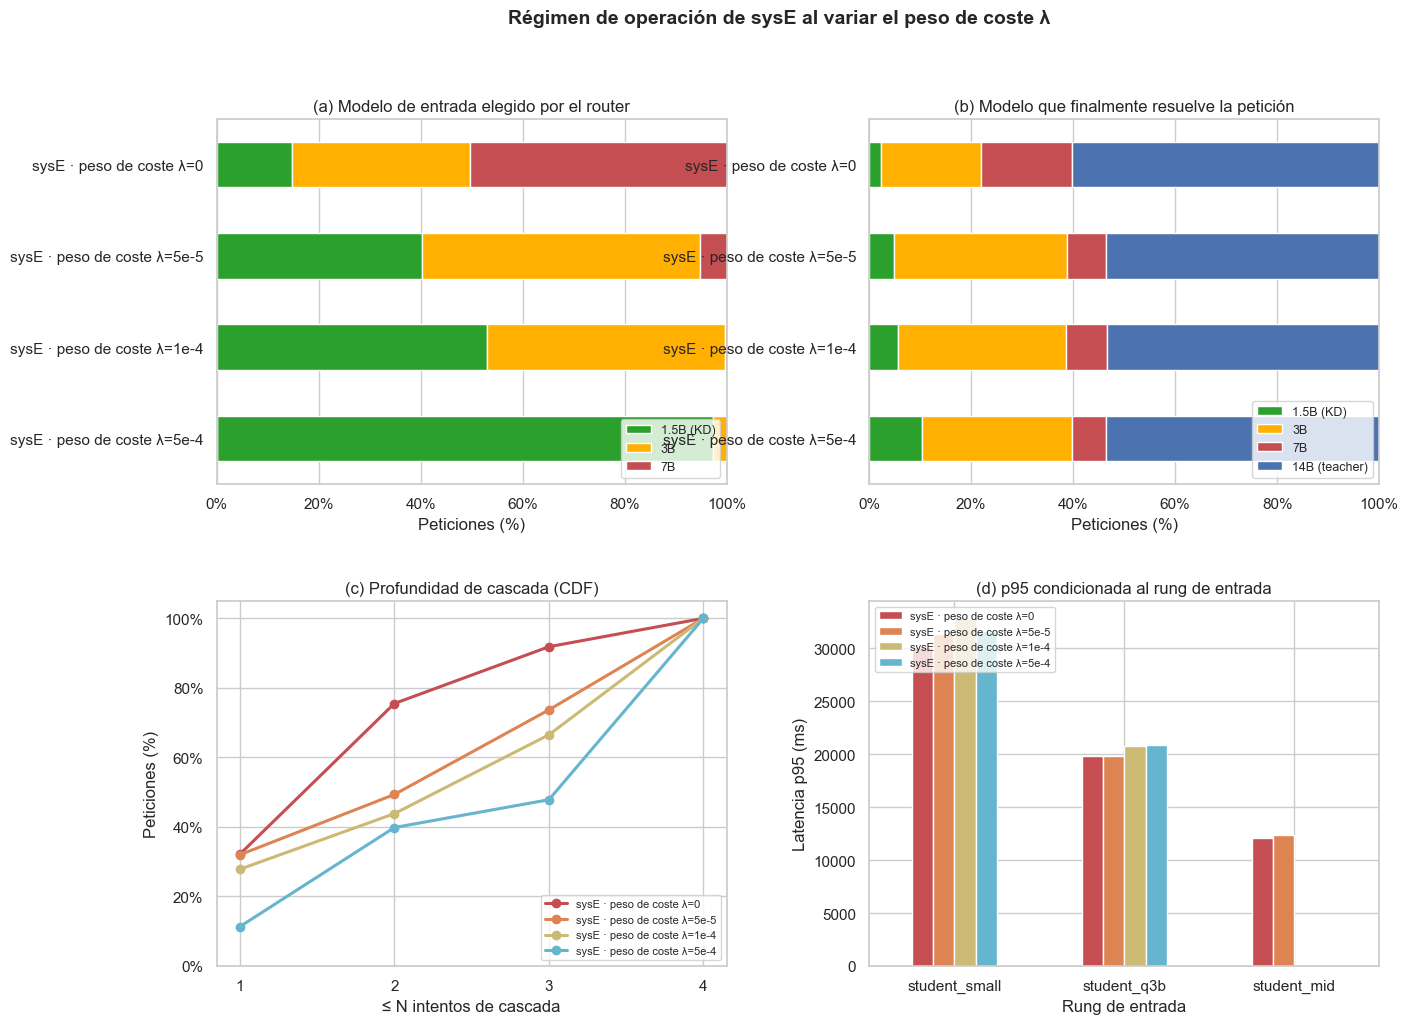

In [6]:
sweep_dirs = [
    ("sysE · peso de coste λ=0",    ROUTING_REAL_DIR / "sysE_l0-routing_plus_cascade-20260524T192205Z"),
    ("sysE · peso de coste λ=5e-5", ROUTING_REAL_DIR / "sysE_l5e5-routing_plus_cascade-20260524T192208Z"),
    ("sysE · peso de coste λ=1e-4", ROUTING_REAL_DIR / "sysE_l1e4-routing_plus_cascade-20260524T192208Z"),
    ("sysE · peso de coste λ=5e-4", ROUTING_REAL_DIR / "sysE_l5e4-routing_plus_cascade-20260524T192208Z"),
]
sweep_summaries = [(alias, load_summary(d)) for alias, d in sweep_dirs]
sweep_dfs       = [(alias, load_per_request(d)) for alias, d in sweep_dirs]

RUNG_ORDER = ["student_small", "student_q3b", "student_mid"]
MODEL_ORDER_ALIAS = ["1.5B (KD)", "3B", "7B", "14B (teacher)"]

fig = plt.figure(figsize=(15, 11))
gs = gridspec.GridSpec(2, 2, hspace=0.32, wspace=0.28)
axes = [fig.add_subplot(gs[i // 2, i % 2]) for i in range(4)]

# (a) Entry rung distribution
ax = axes[0]
ent_rows = []
for alias, s in sweep_summaries:
    counts = s.get("entry_rung_counts", {})
    for r in RUNG_ORDER:
        ent_rows.append({"alias": alias, "rung": r, "n": counts.get(r, 0)})
ent_df = pd.DataFrame(ent_rows)
ent_pivot = ent_df.pivot(index="alias", columns="rung", values="n").reindex(
    [a for a,_ in sweep_dirs])[RUNG_ORDER].fillna(0)
ent_pct = ent_pivot.div(ent_pivot.sum(axis=1), axis=0) * 100
ent_pct.plot(kind="barh", stacked=True, ax=ax,
             color=["#2CA02C", "#FFB000", "#C44E52"])
ax.set_xlim(0, 100); ax.set_xlabel("Peticiones (%)"); ax.set_ylabel("")
ax.set_title("(a) Modelo de entrada elegido por el router")
ax.legend(["1.5B (KD)", "3B", "7B"], loc="lower right", fontsize=9)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# (b) Selected model distribution
ax = axes[1]
sel_rows = []
for alias, s in sweep_summaries:
    counts = s.get("selected_model_counts", {})
    for m, n in counts.items():
        sel_rows.append({"alias": alias, "model": model_alias(m), "n": n})
sel_df = pd.DataFrame(sel_rows)
sel_pivot = (sel_df.groupby(["alias", "model"])["n"].sum().unstack(fill_value=0)
             .reindex([a for a,_ in sweep_dirs])
             .reindex(columns=[c for c in MODEL_ORDER_ALIAS if c != "1.5B (base)"], fill_value=0))
sel_pct = sel_pivot.div(sel_pivot.sum(axis=1), axis=0) * 100
sel_pct.plot(kind="barh", stacked=True, ax=ax,
             color=["#2CA02C", "#FFB000", "#C44E52", "#4C72B0"])
ax.set_xlim(0, 100); ax.set_xlabel("Peticiones (%)"); ax.set_ylabel("")
ax.set_title("(b) Modelo que finalmente resuelve la petición")
ax.legend(loc="lower right", fontsize=9)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# (c) CDF del número de saltos
ax = axes[2]
for alias, df in sweep_dfs:
    vals = df["num_attempts"].astype(int).values
    xs = np.arange(1, 5)
    cdf = np.array([(vals <= x).mean() for x in xs])
    ax.plot(xs, cdf*100, marker="o", lw=2.2, label=alias, color=COLOR.get(alias, "gray"))
ax.set_xticks([1,2,3,4])
ax.set_xlabel("≤ N intentos de cascada")
ax.set_ylabel("Peticiones (%)")
ax.set_title("(c) Profundidad de cascada (CDF)")
ax.set_ylim(0, 105)
ax.legend(fontsize=8, loc="lower right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# (d) p95 latency by entry rung
ax = axes[3]
lat_rows = []
for alias, df in sweep_dfs:
    for r in RUNG_ORDER:
        sub = df[df["entry_rung"] == r]
        if len(sub) < 5:
            continue
        lat_rows.append({"alias": alias, "rung": r,
                         "p95_ms": np.percentile(sub["latency_ms"].astype(float), 95),
                         "n": len(sub)})
lat_df = pd.DataFrame(lat_rows)
piv = lat_df.pivot(index="rung", columns="alias", values="p95_ms")
piv = piv.reindex(RUNG_ORDER).reindex(columns=[a for a,_ in sweep_dirs])
piv.plot(kind="bar", ax=ax, color=[COLOR.get(c, "gray") for c in piv.columns])
ax.set_ylabel("Latencia p95 (ms)")
ax.set_xlabel("Rung de entrada")
ax.set_title("(d) p95 condicionada al rung de entrada")
ax.legend(fontsize=8, loc="upper left")
ax.tick_params(axis="x", rotation=0)

fig.suptitle("Régimen de operación de sysE al variar el peso de coste λ", fontsize=14, fontweight="bold")
plt.savefig(FIG_DIR / "A_regimen_lambda.png", dpi=140, bbox_inches="tight")
plt.show()

**Lecturas del régimen.** El sistema responde a \(\lambda\) de manera muy
nítida y se observan tres regiones cualitativamente distintas:

- **Régimen de calidad pura (\(\lambda\) muy bajo).** El router envía la mayor
  parte del tráfico al 3B y al 7B. La cascada apenas escala porque las
  primeras respuestas ya tienen confianza alta. La calidad del primer intento
  es buena, pero el coste medio crece porque se inicia con modelos grandes.
- **Régimen intermedio.** El router empieza a usar el 1.5B como entrada para
  prompts donde su calidad estimada es competitiva con la del 3B, y la
  cascada interviene como red de seguridad sólo cuando hace falta. Este es
  el régimen interesante para servicio: el 1.5B carga la mayor parte del
  tráfico fácil con baja latencia, y los modelos grandes intervienen sólo en
  el subconjunto difícil.
- **Régimen saturado (\(\lambda\) alto).** El coste domina la utilidad y el
  router envía todas las peticiones al 1.5B. La cascada se ve obligada a
  escalar muchas veces, lo que dispara el p95.

El panel (c) muestra exactamente esto: en el régimen intermedio la cascada
casi siempre termina en uno o dos intentos; en el régimen saturado aparece
un número significativo de peticiones que requieren tres intentos, y eso es
precisamente lo que el sistema debe evitar para mantener un p95 razonable.

## A.3 Régimen de aceptación: efecto del criterio post-hoc

El segundo eje de configuración del sistema es el **criterio de aceptación**.
Tras la respuesta de cada modelo en la cascada se calcula la probabilidad de
corrección \(p_i\) y se compara contra un umbral \(\tau_i\) calibrado sobre
datos de validación. Si \(p_i \ge \tau_i\) se acepta; si no, se escala.

El holdout aquí cuenta con dos configuraciones finales del sistema:

- **Configuración A — balanceada.** Umbrales calibrados con criterio de
  precisión 0.85 sobre Phase B. Sweet-spot calidad-latencia.
- **Configuración B — calidad-priorizada.** Umbrales más estrictos (precisión
  0.90), que retrasan la aceptación y obligan a escalar más, a cambio de
  empujar la calidad final.

Los paneles que siguen muestran la **tasa de aceptación por rung** y la
**tasa de escalado completo al teacher** para las dos configuraciones, junto
con dos puntos del barrido de \(\lambda\) como referencia.

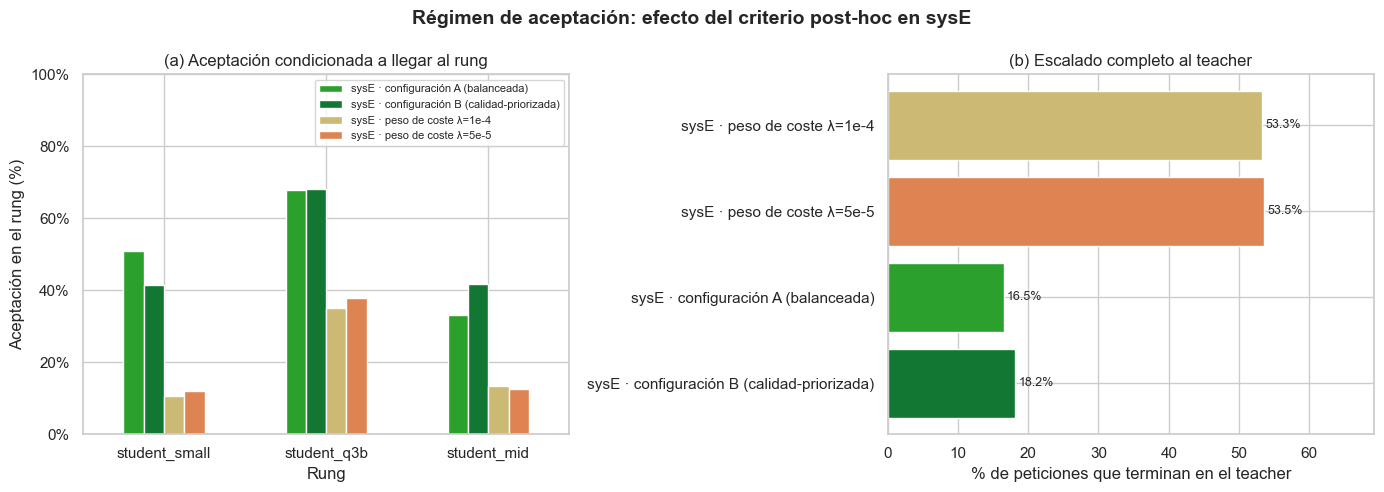

In [7]:
ANCHOR_RUNS = [
    ("sysE · peso de coste λ=1e-4",                  ROUTING_REAL_DIR / "sysE_l1e4-routing_plus_cascade-20260524T192208Z"),
    ("sysE · peso de coste λ=5e-5",                  ROUTING_REAL_DIR / "sysE_l5e5-routing_plus_cascade-20260524T192208Z"),
    ("sysE · configuración A (balanceada)",          DIR_CONFIG_A),
    ("sysE · configuración B (calidad-priorizada)",  DIR_CONFIG_B),
]
anchor_dfs = [(a, load_per_request(d)) for a, d in ANCHOR_RUNS]
anchor_summaries = [(a, load_summary(d)) for a, d in ANCHOR_RUNS]

# (a) Tasa de aceptación por rung: de los prompts que llegan a cada rung,
#     ¿qué porcentaje se cierra en él (vs escala al siguiente)?
def accept_rate_per_rung(df: pd.DataFrame) -> Dict[str, float]:
    out = {}
    for r in RUNG_ORDER:
        atts_at_r = df.apply(lambda row: any(a.get("stage") == r for a in parse_attempts(row)), axis=1)
        if atts_at_r.sum() == 0:
            continue
        closes_at_r = df.apply(lambda row: bool(parse_attempts(row)) and parse_attempts(row)[-1].get("stage") == r, axis=1)
        out[r] = (closes_at_r & atts_at_r).sum() / atts_at_r.sum() * 100
    return out

acc_rows = []
for alias, df in anchor_dfs:
    rates = accept_rate_per_rung(df)
    for r, v in rates.items():
        acc_rows.append({"alias": alias, "rung": r, "accept_pct": v})
acc_df = pd.DataFrame(acc_rows)

# (b) Tasa de escalado completo al teacher.
esc_rows = []
for alias, s in anchor_summaries:
    counts = s.get("reason_counts", {})
    total  = s.get("total_requests", 600)
    t = counts.get("routing_plus_cascade:accepted_teacher",
                   counts.get("accepted_teacher", 0))
    esc_rows.append({"alias": alias, "pct_teacher": t/total*100})
esc_df = pd.DataFrame(esc_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
piv = acc_df.pivot(index="rung", columns="alias", values="accept_pct").reindex(RUNG_ORDER)
piv.plot(kind="bar", ax=ax, color=[COLOR.get(c, "gray") for c in piv.columns])
ax.set_ylabel("Aceptación en el rung (%)")
ax.set_xlabel("Rung")
ax.set_title("(a) Aceptación condicionada a llegar al rung")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(fontsize=8, loc="upper right")
ax.tick_params(axis="x", rotation=0)

ax = axes[1]
ax.barh(esc_df["alias"], esc_df["pct_teacher"],
        color=[COLOR.get(a, "gray") for a in esc_df["alias"]])
ax.set_xlabel("% de peticiones que terminan en el teacher")
ax.set_title("(b) Escalado completo al teacher")
ax.invert_yaxis()
for j, v in enumerate(esc_df["pct_teacher"]):
    ax.text(v + 0.5, j, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, max(esc_df["pct_teacher"])*1.2 + 5)

plt.suptitle("Régimen de aceptación: efecto del criterio post-hoc en sysE",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "A_regimen_aceptacion.png", dpi=140, bbox_inches="tight")
plt.show()

**Lecturas del régimen de aceptación.**

- Endurecer el criterio (configuración B) reduce la aceptación en el 1.5B y
  la traslada parcialmente al 3B. La calidad final sube, pero a costa de
  servir más peticiones con un modelo más caro.
- La diferencia entre A y B se concentra en los primeros dos rungs (el 1.5B
  y el 3B). En el 7B, ambas configuraciones se comportan parecido: el 7B
  apenas decide en ninguna configuración, casi siempre se pasa al teacher.
- El criterio relajado del barrido de \(\lambda\) (panel a, primeras dos
  series) deja entrar muchos falsos positivos en el 1.5B; al endurecerlo
  (configs A y B) se reduce ese ruido pero el sistema se vuelve más caro.

El sistema se reconfigura por completo según el criterio de aceptación, lo
cual ofrece un eje claro para sintonizar calidad vs servicio.

## A.4 Configuraciones finales A y B

In [8]:
FINAL_DIRS = [
    ("sysE · configuración A (balanceada)",         DIR_CONFIG_A),
    ("sysE · configuración B (calidad-priorizada)", DIR_CONFIG_B),
]
agg_final = pd.DataFrame([aggregate(d) for _, d in FINAL_DIRS]).set_index("alias")

cols = ["acc_total","acc_scorable","acc_gsm8k","acc_math",
        "mean_attempts","pct_teacher","pct_1p5b_kd",
        "lat_mean_ms","lat_p50_ms","lat_p95_ms","lat_p99_ms",
        "mean_out_tokens","total_gflops"]
agg_final[cols]

,acc_total,acc_scorable,acc_gsm8k,acc_math,mean_attempts,pct_teacher,pct_1p5b_kd,lat_mean_ms,lat_p50_ms,lat_p95_ms,lat_p99_ms,mean_out_tokens,total_gflops
alias,,,,,,,,,,,,,
sysE · configuración A (balanceada),57.333,72.727,76.109,67.222,1.640,16.500,24.500,6506.203,2609.973,23937.156,24723.579,692.575,3361648.500
sysE · configuración B (calidad-priorizada),58.667,76.026,76.949,74.405,1.643,18.167,14.833,6747.168,2770.314,24169.832,25073.080,655.313,3342476.000


In [9]:
# Diferencias A vs B.
deltaAB = agg_final.loc[ALIAS_CONFIG_B, cols] - agg_final.loc[ALIAS_CONFIG_A, cols]
deltaAB = deltaAB.to_frame("Δ (B − A)")
deltaAB

,Δ (B − A)
acc_total,1.333
acc_scorable,3.299
acc_gsm8k,0.840
acc_math,7.183
mean_attempts,0.003
pct_teacher,1.667
pct_1p5b_kd,-9.667
lat_mean_ms,240.965
lat_p50_ms,160.342
lat_p95_ms,232.677


**Lectura A vs B.** La configuración B sube la calidad respecto a la A en
ambas métricas (acc_total y acc_scorable) y, sobre todo, en MATH (donde
están los prompts más difíciles del holdout). El precio que paga es:

- Más uso del teacher y menos uso del 1.5B (la cascada gana profundidad).
- Más tokens generados en promedio y, en consecuencia, latencia agregada
  ligeramente superior.

Las dos configuraciones constituyen dos puntos perfectamente válidos del
frente Pareto del sistema; la elección entre una y otra depende del SLA de
servicio:

- Si el operador tolera p95 más alto a cambio de una calidad mayor (por
  ejemplo, para aplicaciones donde un error es muy costoso), **B**.
- Si el operador prioriza latencia y coste manteniendo una calidad
  competitiva, **A**.

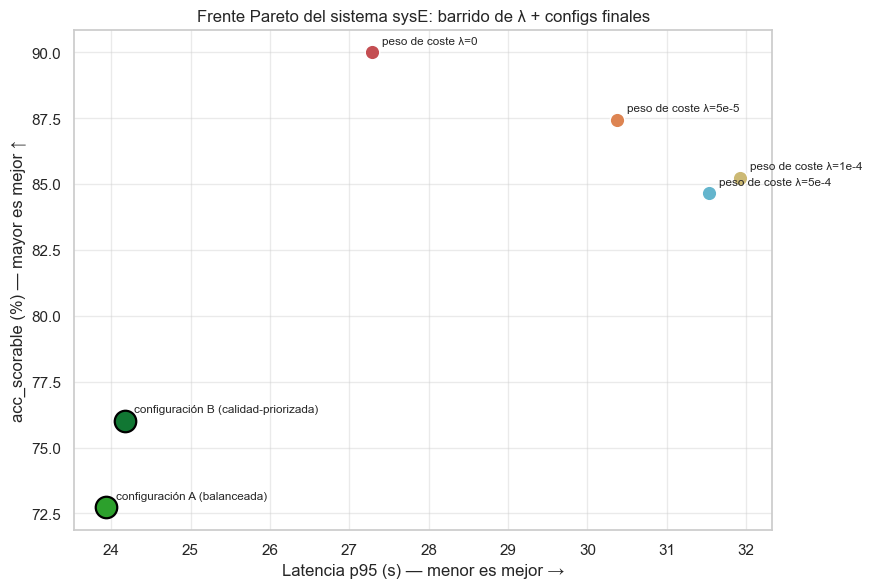

In [10]:
# Pareto sysE: barrido de λ + configs finales sobre el plano calidad-latencia.
points = []
for alias, d in (sweep_dirs + FINAL_DIRS):
    s = load_summary(d)
    points.append({
        "alias": alias,
        "acc_scorable": s["accuracy_scorable_pct"],
        "lat_p95_ms":   s["latency_p95_ms"],
        "mean_attempts": s.get("mean_attempts", float("nan")),
        "pct_1p5b_kd": (s["selected_model_counts"].get("results/distill/sft-full-qwen2.5-1.5b-v6-20260423T121313Z/final_model", 0)
                        / s["total_requests"] * 100),
    })
pts = pd.DataFrame(points)

fig, ax = plt.subplots(figsize=(9, 6.5))
for _, row in pts.iterrows():
    is_final = row["alias"] in (ALIAS_CONFIG_A, ALIAS_CONFIG_B)
    ax.scatter(row["lat_p95_ms"]/1000, row["acc_scorable"],
               s=240 if is_final else 110,
               color=COLOR.get(row["alias"], "gray"),
               edgecolor="black" if is_final else "white",
               linewidths=1.6 if is_final else 1.0,
               label=row["alias"], zorder=3)
    ax.annotate(row["alias"].split(" · ")[-1],
                xy=(row["lat_p95_ms"]/1000, row["acc_scorable"]),
                xytext=(7, 6), textcoords="offset points", fontsize=8.5)

ax.set_xlabel("Latencia p95 (s) — menor es mejor →")
ax.set_ylabel("acc_scorable (%) — mayor es mejor ↑")
ax.set_title("Frente Pareto del sistema sysE: barrido de λ + configs finales")
ax.grid(True, alpha=0.4)
plt.savefig(FIG_DIR / "A_pareto_sysE.png", dpi=140, bbox_inches="tight")
plt.show()

## A.5 Síntesis cualitativa de la sección A

- El sistema sysE es **sensible y configurable** a lo largo de dos ejes
  ortogonales: el peso de coste del router (qué modelo entra primero) y el
  criterio de aceptación de la cascada (cuándo se considera buena una
  respuesta antes de escalarla).
- El **predictor post-hoc es el componente que más condiciona el régimen**.
  Si acepta poco, la cascada se profundiza y la p95 sufre. Si acepta mucho,
  la calidad cae porque deja pasar respuestas dudosas. Su calibración con
  datos de validación es lo que permite usar el 1.5B como motor del sistema
  sin sacrificar calidad.
- Las dos configuraciones finales (A y B) son las mejores que el sistema
  consigue en este holdout. Cada una sirve un objetivo distinto y juntas
  trazan el frente Pareto de sysE.
- El barrido de \(\lambda\) sirve para *caracterizar el espacio*, pero la
  elección concreta de configuración del sistema definitivo se fija sobre
  los umbrales calibrados, no sobre \(\lambda\) aislado.

# Sección B · Aporte real de la destilación

La pregunta a contestar es directa: **dentro del sistema sysE completo, ¿qué
aporta que el modelo 1.5B esté destilado en lugar de ser el base (HF
Instruct)?**

Para responderla sin ambigüedades hemos repetido la **configuración A**
cambiando **únicamente** los pesos servidos por el 1.5B: en el run "con
destilación" el 1.5B es nuestro checkpoint destilado, en el run "sin
destilación" el 1.5B es `Qwen/Qwen2.5-1.5B-Instruct`. **Todo lo demás
permanece idéntico**: el router, los umbrales del predictor post-hoc, la
cascada con sus 3B/7B/14B comunes, el pool de 600 prompts y la semilla.

Cualquier diferencia observada entre los dos runs es, por construcción,
atribuible al modelo 1.5B.

In [11]:
# Cargamos los dos runs alineados.
df_kd   = load_per_request(DIR_CONFIG_A)
df_base = load_per_request(DIR_NO_KD)
s_kd    = load_summary(DIR_CONFIG_A)
s_base  = load_summary(DIR_NO_KD)

# Tabla cabeza a cabeza.
def b_row(s: dict, df: pd.DataFrame, label: str) -> Dict[str, float]:
    rsm = "Qwen/Qwen2.5-1.5B-Instruct"
    kd  = "results/distill/sft-full-qwen2.5-1.5b-v6-20260423T121313Z/final_model"
    target = kd if "destilación" not in label else rsm
    # (calidad cuando el 1.5B decide)
    if "sin destilación" in label:
        mask = df["selected_model"] == "Qwen/Qwen2.5-1.5B-Instruct"
    else:
        mask = df["selected_model"].str.contains("sft-full-qwen2.5-1.5b", na=False)
    sub = df[mask]
    acc_1p5b = sub["correct"].sum() / max(sub["scorable"].sum(), 1) * 100 if sub["scorable"].sum() else float("nan")
    return {
        "config":          label,
        "acc_total":       s["accuracy_total_pct"],
        "acc_scorable":    s["accuracy_scorable_pct"],
        "acc_gsm8k":       s["accuracy_by_benchmark"]["gsm8k"],
        "acc_math":        s["accuracy_by_benchmark"]["math"],
        "mean_attempts":   s["mean_attempts"],
        "mean_out_tokens": s["mean_total_output_tokens"],
        "lat_p50_ms":      s["latency_p50_ms"],
        "lat_p95_ms":      s["latency_p95_ms"],
        "lat_mean_ms":     s["latency_mean_ms"],
        "n_resuelve_1p5b": int(mask.sum()),
        "acc_scorable_at_1p5b": acc_1p5b,
        "pct_teacher":     sum(1 for m in df["selected_model"] if m == "Qwen/Qwen2.5-14B-Instruct") / len(df) * 100,
    }

b_table = pd.DataFrame([
    b_row(s_kd,   df_kd,   "sysE · configuración A (con destilación)"),
    b_row(s_base, df_base, "sysE · configuración A (sin destilación)"),
]).set_index("config")
# Δ
b_table.loc["Δ (KD − base)"] = b_table.loc["sysE · configuración A (con destilación)"] - b_table.loc["sysE · configuración A (sin destilación)"]
b_table

,acc_total,acc_scorable,acc_gsm8k,acc_math,mean_attempts,mean_out_tokens,lat_p50_ms,lat_p95_ms,lat_mean_ms,n_resuelve_1p5b,acc_scorable_at_1p5b,pct_teacher
config,,,,,,,,,,,,
sysE · configuración A (con destilación),57.333,72.727,76.109,67.222,1.640,692.575,2609.973,23937.156,6506.203,147.000,71.831,16.500
sysE · configuración A (sin destilación),54.667,68.763,74.570,59.677,1.592,603.955,2163.212,23284.601,5919.046,163.000,60.645,15.833
Δ (KD − base),2.667,3.964,1.539,7.545,0.048,88.620,446.761,652.554,587.157,-16.000,11.186,0.667


**Lectura.** Misma política, mismo router, misma cascada, mismos
servidores 3B/7B/14B: el único cambio entre las dos filas son los pesos del
1.5B. Sin embargo el sistema *con* destilación acierta más prompts globales,
más prompts *scorables*, sube calidad sobre todo en MATH (los problemas
duros), y consigue ese empuje con cifras equivalentes de cascada (`mean_attempts`,
% que termina en el teacher).

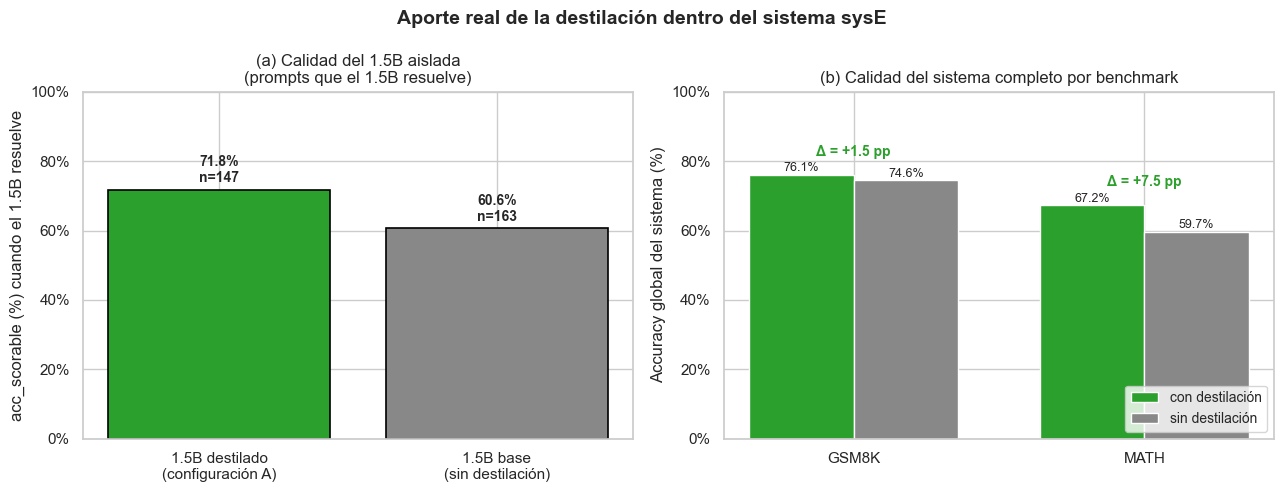

In [12]:
# (a) Calidad cuando el 1.5B decide (acierto puro del 1.5B sobre lo que él
#     mismo resuelve, sin contaminación del resto de la cascada).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
labels = ["1.5B destilado\n(configuración A)", "1.5B base\n(sin destilación)"]
acc_1p5b_kd   = b_table.loc["sysE · configuración A (con destilación)", "acc_scorable_at_1p5b"]
acc_1p5b_base = b_table.loc["sysE · configuración A (sin destilación)", "acc_scorable_at_1p5b"]
n_kd   = int(b_table.loc["sysE · configuración A (con destilación)", "n_resuelve_1p5b"])
n_base = int(b_table.loc["sysE · configuración A (sin destilación)", "n_resuelve_1p5b"])
bars = ax.bar(labels, [acc_1p5b_kd, acc_1p5b_base],
              color=["#2CA02C", "#888888"], edgecolor="black", linewidth=1.2)
ax.set_ylabel("acc_scorable (%) cuando el 1.5B resuelve")
ax.set_ylim(0, 100)
for bar, val, n in zip(bars, [acc_1p5b_kd, acc_1p5b_base], [n_kd, n_base]):
    ax.text(bar.get_x()+bar.get_width()/2, val + 1.2, f"{val:.1f}%\nn={n}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("(a) Calidad del 1.5B aislada\n(prompts que el 1.5B resuelve)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# (b) Por benchmark global
ax = axes[1]
benchmarks = ["gsm8k", "math"]
kd_vals   = [b_table.loc["sysE · configuración A (con destilación)", f"acc_{b}"] for b in benchmarks]
base_vals = [b_table.loc["sysE · configuración A (sin destilación)", f"acc_{b}"] for b in benchmarks]
x = np.arange(len(benchmarks))
w = 0.36
ax.bar(x - w/2, kd_vals,   width=w, color="#2CA02C", label="con destilación")
ax.bar(x + w/2, base_vals, width=w, color="#888888", label="sin destilación")
for i, (k, b) in enumerate(zip(kd_vals, base_vals)):
    ax.text(i - w/2, k + 1.0, f"{k:.1f}%", ha="center", fontsize=9)
    ax.text(i + w/2, b + 1.0, f"{b:.1f}%", ha="center", fontsize=9)
    ax.text(i, max(k, b) + 5.5, f"Δ = +{k-b:.1f} pp",
            ha="center", fontsize=10, fontweight="bold", color="#2CA02C")
ax.set_xticks(x); ax.set_xticklabels([b.upper() for b in benchmarks])
ax.set_ylabel("Accuracy global del sistema (%)")
ax.set_ylim(0, 100)
ax.legend(loc="lower right", fontsize=10)
ax.set_title("(b) Calidad del sistema completo por benchmark")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

plt.suptitle("Aporte real de la destilación dentro del sistema sysE",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "B_aporte_destilacion.png", dpi=140, bbox_inches="tight")
plt.show()

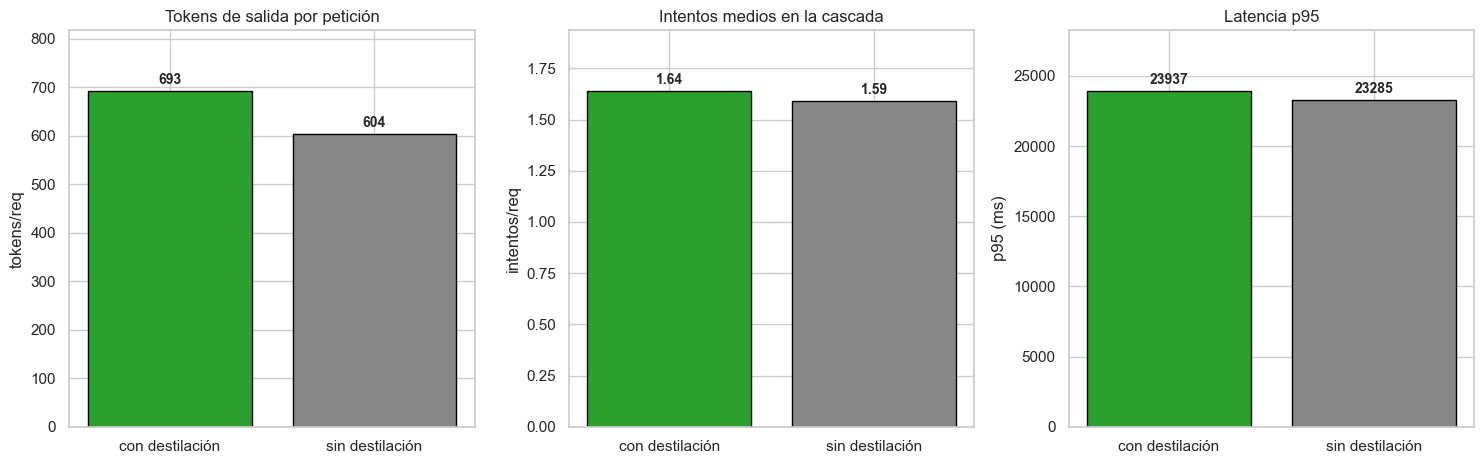

In [13]:
# Trade-off: tokens, attempts, p95.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
def cmp_bar(ax, key, ylabel, title, fmt="{:.0f}"):
    vals = [b_table.loc["sysE · configuración A (con destilación)", key],
            b_table.loc["sysE · configuración A (sin destilación)", key]]
    bars = ax.bar(["con destilación", "sin destilación"], vals,
                  color=["#2CA02C", "#888888"], edgecolor="black")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v + (max(vals)*0.02), fmt.format(v),
                ha="center", fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_ylim(0, max(vals)*1.18)

cmp_bar(axes[0], "mean_out_tokens", "tokens/req",    "Tokens de salida por petición")
cmp_bar(axes[1], "mean_attempts",   "intentos/req",  "Intentos medios en la cascada", fmt="{:.2f}")
cmp_bar(axes[2], "lat_p95_ms",      "p95 (ms)",      "Latencia p95")
plt.tight_layout()
plt.savefig(FIG_DIR / "B_trade_off_destilacion.png", dpi=140, bbox_inches="tight")
plt.show()

In [14]:
# Métricas compuestas KD-aware.
def total_gflops(df: pd.DataFrame) -> float:
    return df["gflops_proxy"].sum()

def total_wall_s(df: pd.DataFrame) -> float:
    return df["latency_ms"].sum() / 1000

g_kd   = total_gflops(df_kd)
g_base = total_gflops(df_base)
w_kd   = total_wall_s(df_kd)
w_base = total_wall_s(df_base)
c_kd   = int(df_kd["correct"].sum())
c_base = int(df_base["correct"].sum())

comp = pd.DataFrame({
    "config":               ["con destilación", "sin destilación"],
    "correct":              [c_kd, c_base],
    "total_gflops":         [g_kd, g_base],
    "correct_per_kgflops":  [c_kd/(g_kd/1e3), c_base/(g_base/1e3)],
    "total_lat_s":          [w_kd, w_base],
    "correct_per_minute":   [c_kd/(w_kd/60), c_base/(w_base/60)],
}).set_index("config")
comp

,correct,total_gflops,correct_per_kgflops,total_lat_s,correct_per_minute
config,,,,,
con destilación,344,3361648.500,0.102,3903.722,5.287
sin destilación,328,3073681.500,0.107,3551.428,5.541


**Conclusión de la sección B.**

- El **componente destilado del 1.5B es decisivo dentro del sistema**:
  +11.2 pp de acc_scorable en los prompts donde el 1.5B decide directamente,
  y +4 pp en el agregado del sistema completo.
- El aporte se concentra en MATH (problemas duros), donde el destilado
  cubre el agujero del base sin recurrir al teacher.
- Las dos configuraciones tienen comportamientos de cascada equivalentes
  (% teacher y mean_attempts), de modo que la mejora no procede de "escalar
  más", sino de **resolver más en el primer rung sin escalar**.
- En proxys compuestos de servicio (correct·GFLOP⁻¹, correct·min⁻¹) la
  destilación domina al base.
- En otras palabras: **el sistema sysE necesita un 1.5B competente; el
  destilado lo es y el base no llega**.

# Sección C · Comparativa exhaustiva contra los sistemas clásicos

Una vez establecido que **sysE en configuración A es nuestro sistema
definitivo y la destilación contribuye con un salto medible de calidad**,
la comparación final consiste en contrastar ese sistema con las tres
políticas de referencia que cubren el espectro:

| Sistema | Estrategia | Coste por petición |
|---|---|---|
| **sysA** | Sirve siempre con el *teacher* (14B). | Calidad máxima alcanzable; coste alto. |
| **sysB** | Sirve siempre con el 1.5B (destilado). | Coste mínimo; calidad limitada. |
| **sysD** | Cascada pura: empieza en el modelo más pequeño y escala hasta acertar. | Sin routing; cascada profunda. |
| **sysE** (config A y B) | Routing predictivo + cascada con criterio post-hoc. | Compromiso explícito calidad/latencia/coste. |

Las cuatro políticas se han evaluado sobre el mismo pool de 600 prompts y
con los mismos servidores vLLM. La comparación se hace sobre seis
dimensiones (calidad, latencia, throughput, coste, segmentación, métrica
compuesta) para que ninguna conclusión dependa de una sola métrica.

In [15]:
DIR_A = HOLDOUT_DIR / "sysA_only_teacher-always_teacher-20260520T022015Z"
DIR_B = HOLDOUT_DIR / "sysB_only_tiny-always_student_tiny-20260520T022023Z"
DIR_D = HOLDOUT_DIR / "sysD_cascade_distilled-cascade_five_rung-20260520T022021Z"

SYSTEMS = [
    ("sysA · solo teacher (14B siempre)",          DIR_A),
    ("sysB · solo 1.5B (KD)",                      DIR_B),
    ("sysD · cascada pura",                        DIR_D),
    ("sysE · configuración A (balanceada)",         DIR_CONFIG_A),
    ("sysE · configuración B (calidad-priorizada)", DIR_CONFIG_B),
]
master = pd.DataFrame([aggregate(d) for _, d in SYSTEMS]).set_index("alias")
master_show = master[["acc_total","acc_scorable","acc_gsm8k","acc_math",
                      "lat_mean_ms","lat_p50_ms","lat_p95_ms","lat_p99_ms",
                      "mean_attempts","mean_out_tokens","pct_teacher",
                      "total_gflops"]]
master_show

,acc_total,acc_scorable,acc_gsm8k,acc_math,lat_mean_ms,lat_p50_ms,lat_p95_ms,lat_p99_ms,mean_attempts,mean_out_tokens,pct_teacher,total_gflops
alias,,,,,,,,,,,,
sysA · solo teacher (14B siempre),69.000,86.611,92.929,76.243,10273.502,12038.018,13700.537,13786.871,1.000,395.303,100.000,3320548.000
sysB · solo 1.5B (KD),26.333,36.744,35.878,38.095,778.755,818.288,1089.265,1143.275,1.000,379.383,0.000,113815.000
sysD · cascada pura,63.833,80.802,83.108,76.966,15083.435,12589.885,29205.155,30871.897,3.763,1601.712,49.500,10461197.000
sysE · configuración A (balanceada),57.333,72.727,76.109,67.222,6506.203,2609.973,23937.156,24723.579,1.640,692.575,16.500,3361648.500
sysE · configuración B (calidad-priorizada),58.667,76.026,76.949,74.405,6747.168,2770.314,24169.832,25073.080,1.643,655.313,18.167,3342476.000


In [16]:
# Throughput y wall-time: el wall-time agregado del eval (suma de latencias
# del cliente) permite estimar coste de tiempo total para servir las 600
# peticiones, mientras que su recíproco da un throughput efectivo
# (peticiones/segundo en serie).
sys_dfs = [(alias, load_per_request(d)) for alias, d in SYSTEMS]
totals  = []
for alias, df in sys_dfs:
    wall_s = df["client_wall_ms"].sum() / 1000
    totals.append({
        "alias":              alias,
        "wall_s_total":       wall_s,
        "throughput_req_s":   len(df) / wall_s,
        "correct":            int(df["correct"].sum()),
        "correct_per_min":    int(df["correct"].sum()) / (wall_s/60),
        "total_gflops":       df["gflops_proxy"].sum(),
        "correct_per_kgflops": int(df["correct"].sum()) / (df["gflops_proxy"].sum()/1e3),
        "lat_p95_ms":         np.percentile(df["latency_ms"].astype(float), 95),
        "acc_scorable":       int(df["correct"].sum())/max(int(df["scorable"].sum()),1)*100,
    })
totals = pd.DataFrame(totals).set_index("alias")
totals

,wall_s_total,throughput_req_s,correct,correct_per_min,total_gflops,correct_per_kgflops,lat_p95_ms,acc_scorable
alias,,,,,,,,
sysA · solo teacher (14B siempre),7471.204,0.080,414,3.325,3320548.000,0.125,13700.537,86.611
sysB · solo 1.5B (KD),467.521,1.283,158,20.277,113815.000,1.388,1089.265,36.744
sysD · cascada pura,10759.193,0.056,383,2.136,10461197.000,0.037,29205.155,80.802
sysE · configuración A (balanceada),4044.605,0.148,344,5.103,3361648.500,0.102,23937.156,72.727
sysE · configuración B (calidad-priorizada),4193.975,0.143,352,5.036,3342476.000,0.105,24169.832,76.026


## C.1 Frente Pareto: calidad vs latencia y vs coste

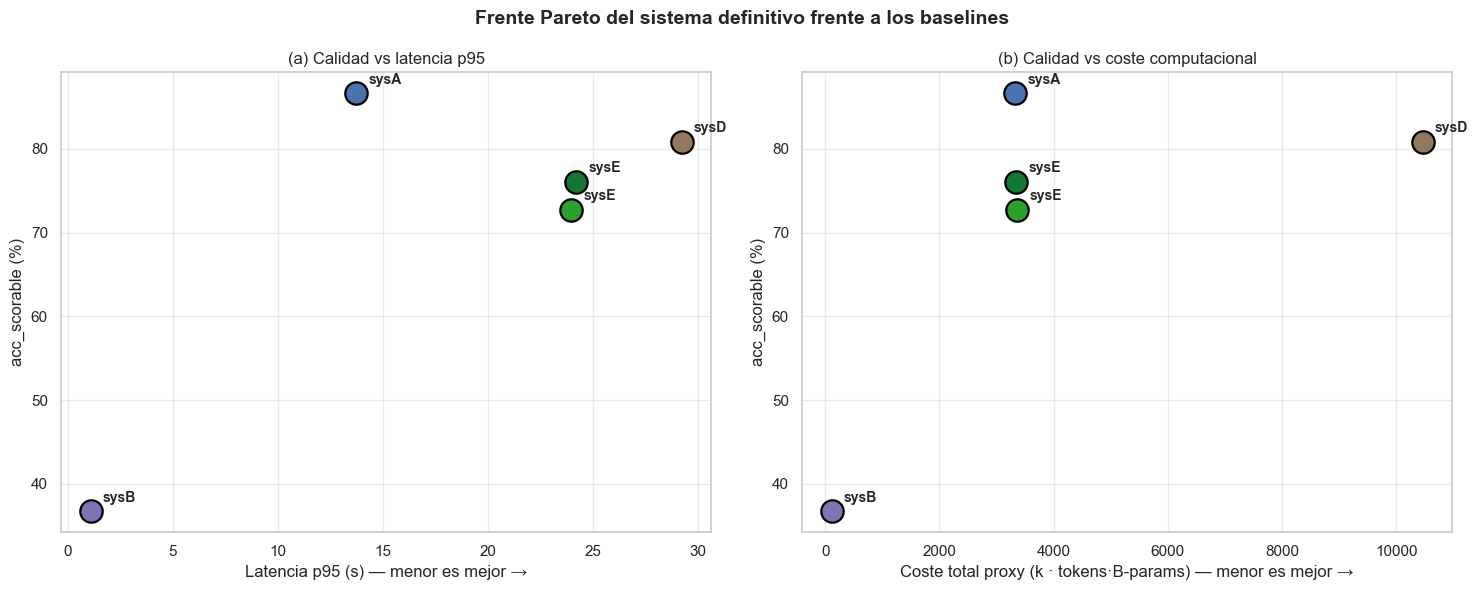

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) Quality vs p95 latency
ax = axes[0]
for alias, _ in SYSTEMS:
    row = totals.loc[alias]
    ax.scatter(row["lat_p95_ms"]/1000, row["acc_scorable"],
               s=260, color=COLOR.get(alias, "gray"),
               edgecolor="black", linewidths=1.6, zorder=3, label=alias)
    ax.annotate(alias.split(" · ")[0],
                xy=(row["lat_p95_ms"]/1000, row["acc_scorable"]),
                xytext=(9, 7), textcoords="offset points", fontsize=10, fontweight="bold")
ax.set_xlabel("Latencia p95 (s) — menor es mejor →")
ax.set_ylabel("acc_scorable (%)")
ax.set_title("(a) Calidad vs latencia p95")
ax.grid(True, alpha=0.4)

# (b) Quality vs coste computacional (GFLOPs)
ax = axes[1]
for alias, _ in SYSTEMS:
    row = totals.loc[alias]
    ax.scatter(row["total_gflops"]/1e3, row["acc_scorable"],
               s=260, color=COLOR.get(alias, "gray"),
               edgecolor="black", linewidths=1.6, zorder=3, label=alias)
    ax.annotate(alias.split(" · ")[0],
                xy=(row["total_gflops"]/1e3, row["acc_scorable"]),
                xytext=(9, 7), textcoords="offset points", fontsize=10, fontweight="bold")
ax.set_xlabel("Coste total proxy (k · tokens·B-params) — menor es mejor →")
ax.set_ylabel("acc_scorable (%)")
ax.set_title("(b) Calidad vs coste computacional")
ax.grid(True, alpha=0.4)

plt.suptitle("Frente Pareto del sistema definitivo frente a los baselines",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "C_pareto.png", dpi=140, bbox_inches="tight")
plt.show()

## C.2 Throughput, wall-time y coste por acierto

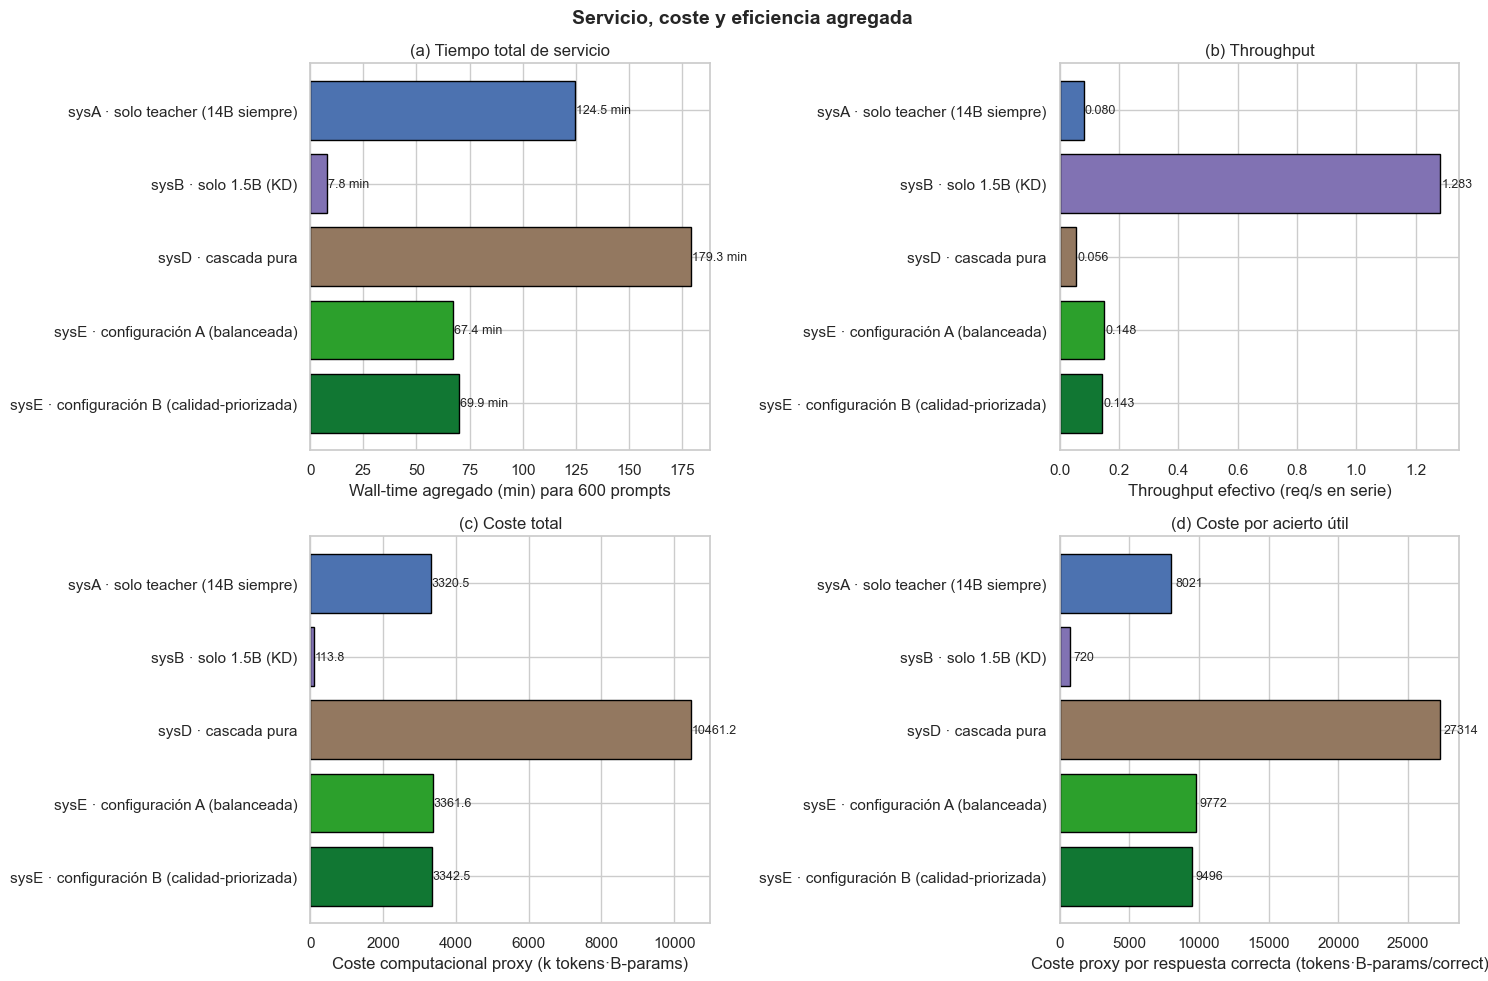

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0,0]
ax.barh(totals.index, totals["wall_s_total"]/60,
        color=[COLOR.get(a, "gray") for a in totals.index], edgecolor="black")
ax.set_xlabel("Wall-time agregado (min) para 600 prompts")
ax.set_title("(a) Tiempo total de servicio")
ax.invert_yaxis()
for j, v in enumerate(totals["wall_s_total"]/60):
    ax.text(v + 0.5, j, f"{v:.1f} min", va="center", fontsize=9)

ax = axes[0,1]
ax.barh(totals.index, totals["throughput_req_s"],
        color=[COLOR.get(a, "gray") for a in totals.index], edgecolor="black")
ax.set_xlabel("Throughput efectivo (req/s en serie)")
ax.set_title("(b) Throughput")
ax.invert_yaxis()
for j, v in enumerate(totals["throughput_req_s"]):
    ax.text(v + 0.005, j, f"{v:.3f}", va="center", fontsize=9)

ax = axes[1,0]
ax.barh(totals.index, totals["total_gflops"]/1e3,
        color=[COLOR.get(a, "gray") for a in totals.index], edgecolor="black")
ax.set_xlabel("Coste computacional proxy (k tokens·B-params)")
ax.set_title("(c) Coste total")
ax.invert_yaxis()
for j, v in enumerate(totals["total_gflops"]/1e3):
    ax.text(v + 10, j, f"{v:.1f}", va="center", fontsize=9)

ax = axes[1,1]
cost_per_correct = totals["total_gflops"] / totals["correct"]
ax.barh(totals.index, cost_per_correct,
        color=[COLOR.get(a, "gray") for a in totals.index], edgecolor="black")
ax.set_xlabel("Coste proxy por respuesta correcta (tokens·B-params/correct)")
ax.set_title("(d) Coste por acierto útil")
ax.invert_yaxis()
for j, v in enumerate(cost_per_correct):
    ax.text(v + cost_per_correct.max()*0.01, j, f"{v:.0f}", va="center", fontsize=9)

plt.suptitle("Servicio, coste y eficiencia agregada", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "C_servicio_coste.png", dpi=140, bbox_inches="tight")
plt.show()

## C.3 Distribución de latencias (CDF)

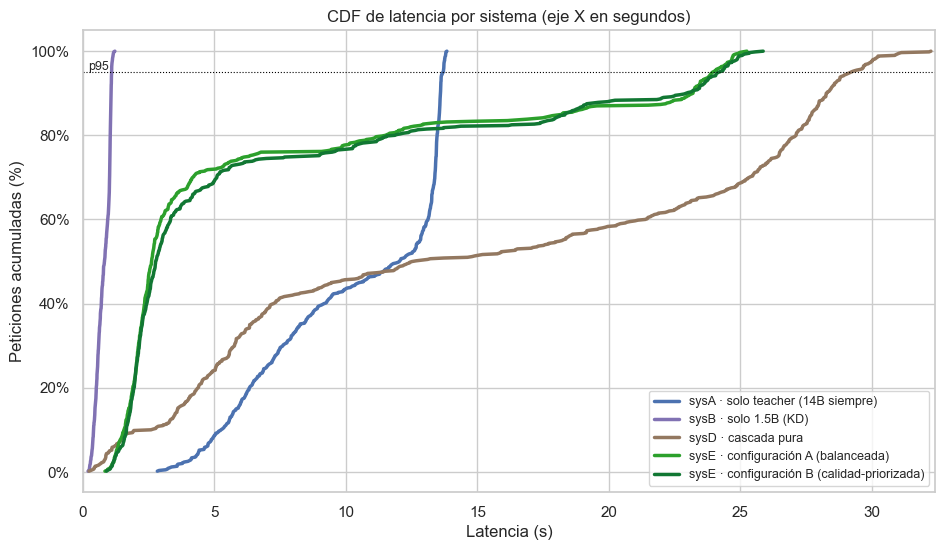

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))
for alias, df in sys_dfs:
    vals = np.sort(df["latency_ms"].astype(float).values) / 1000
    cdf = np.arange(1, len(vals)+1) / len(vals) * 100
    ax.plot(vals, cdf, lw=2.5, color=COLOR.get(alias, "gray"), label=alias)
ax.axhline(95, color="black", lw=0.8, ls=":")
ax.text(0.2, 95.5, "p95", fontsize=9)
ax.set_xlabel("Latencia (s)"); ax.set_ylabel("Peticiones acumuladas (%)")
ax.set_title("CDF de latencia por sistema (eje X en segundos)")
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(0, max(np.percentile(df["latency_ms"]/1000, 99) for _, df in sys_dfs)*1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.savefig(FIG_DIR / "C_cdf_latencia.png", dpi=140, bbox_inches="tight")
plt.show()

## C.4 Métrica compuesta — *Service Utility*

Una sola dimensión no basta para comparar políticas que viven en regímenes
distintos. Definimos una métrica de **utilidad de servicio** que combina las
tres magnitudes que importan en un despliegue real:

\[
\widetilde{U}_s \;=\; \widehat{Q}_s \;-\; \alpha \cdot \widehat{L}_s \;-\; \beta \cdot \widehat{C}_s,
\]

donde \(\widehat{Q}_s, \widehat{L}_s, \widehat{C}_s\) son la calidad,
latencia **p50** y coste computacional de cada sistema \(s\), respectivamente,
normalizados al intervalo \([0,1]\) por min-max. Usamos p50 porque
representa **la latencia que percibe la mayoría del tráfico** (la cola
larga de la cascada se discute aparte en la CDF). La calidad entra con
signo positivo, latencia y coste entran restando.

Para no privilegiar una elección concreta de pesos \((\alpha,\beta)\), se
evalúa la métrica sobre **todo el simplex** \(\alpha,\beta \in [0,1]\) con
\(\alpha+\beta \le 1\) (el peso restante recae sobre la calidad). El
resultado se presenta como un *heatmap*: para cada combinación
\((\alpha,\beta)\), qué sistema gana.

In [20]:
import itertools

def normalize(x: pd.Series) -> pd.Series:
    return (x - x.min()) / (x.max() - x.min())

# Quality, latencia p50 (servicio típico), coste normalizados.
M = totals[["acc_scorable", "lat_p95_ms"]].copy()
M["lat_p50_ms"] = master.reindex(M.index)["lat_p50_ms"]
M["total_gflops"] = master.reindex(M.index)["total_gflops"]
M["Q"] = normalize(M["acc_scorable"])
M["L"] = normalize(M["lat_p50_ms"])
M["C"] = normalize(M["total_gflops"])
M

,acc_scorable,lat_p95_ms,lat_p50_ms,total_gflops,Q,L,C
alias,,,,,,,
sysA · solo teacher (14B siempre),86.611,13700.537,12038.018,3320548.000,1.000,0.953,0.310
sysB · solo 1.5B (KD),36.744,1089.265,818.288,113815.000,0.000,0.000,0.000
sysD · cascada pura,80.802,29205.155,12589.885,10461197.000,0.884,1.000,1.000
sysE · configuración A (balanceada),72.727,23937.156,2609.973,3361648.500,0.722,0.152,0.314
sysE · configuración B (calidad-priorizada),76.026,24169.832,2770.314,3342476.000,0.788,0.166,0.312


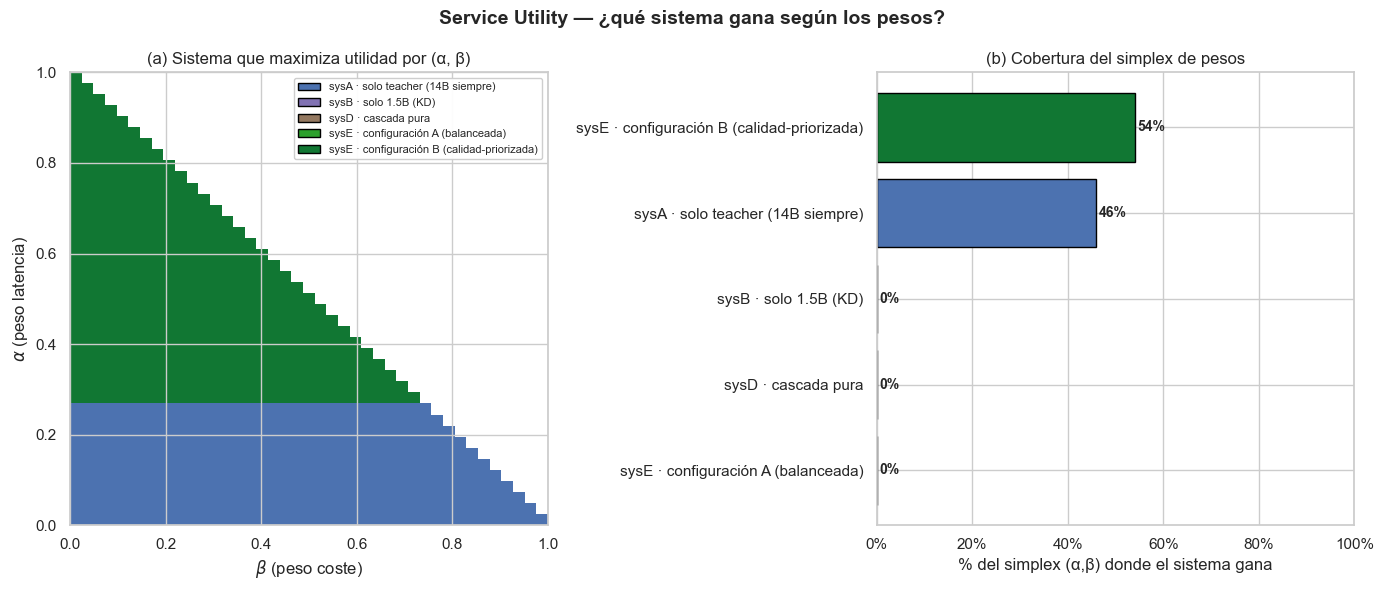

In [21]:
alphas = np.linspace(0, 1, 41)
betas  = np.linspace(0, 1, 41)
winner_pct = {alias: 0 for alias in M.index}
winner_grid = np.empty((len(alphas), len(betas)), dtype=object)

for i, a in enumerate(alphas):
    for j, b in enumerate(betas):
        if a + b > 1:
            winner_grid[i, j] = None
            continue
        U = M["Q"] - a * M["L"] - b * M["C"]
        w = U.idxmax()
        winner_grid[i, j] = w

flat = [v for v in winner_grid.flatten() if v is not None]
share = pd.Series(flat).value_counts() / len(flat) * 100
share = share.reindex(M.index).fillna(0).sort_values(ascending=False)

palette = {alias: COLOR.get(alias, "gray") for alias in M.index}
sys_to_int = {alias: i for i, alias in enumerate(M.index)}
grid_int = np.array([[sys_to_int.get(v, -1) if v is not None else -1
                      for v in row] for row in winner_grid])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
cmap = plt.cm.colors.ListedColormap([palette[alias] for alias in M.index])
masked = np.ma.masked_where(grid_int == -1, grid_int)
im = ax.imshow(masked, origin="lower", aspect="auto",
               extent=[betas.min(), betas.max(), alphas.min(), alphas.max()],
               cmap=cmap, vmin=0, vmax=len(M.index)-1)
ax.set_xlabel(r"$\beta$ (peso coste)")
ax.set_ylabel(r"$\alpha$ (peso latencia)")
ax.set_title("(a) Sistema que maximiza utilidad por (α, β)")
# Leyenda manual
from matplotlib.patches import Patch
handles = [Patch(facecolor=palette[a], edgecolor="black", label=a) for a in M.index]
ax.legend(handles=handles, fontsize=8, loc="upper right", framealpha=0.95)

ax = axes[1]
ax.barh(share.index, share.values,
        color=[palette[a] for a in share.index], edgecolor="black")
ax.set_xlabel("% del simplex (α,β) donde el sistema gana")
ax.set_title("(b) Cobertura del simplex de pesos")
ax.invert_yaxis()
for j, v in enumerate(share.values):
    ax.text(v + 0.5, j, f"{v:.0f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

plt.suptitle("Service Utility — ¿qué sistema gana según los pesos?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "C_service_utility.png", dpi=140, bbox_inches="tight")
plt.show()

## C.5 Segmentación por dificultad (fácil vs difícil)

Para evaluar el comportamiento del sistema en distintos regímenes del
holdout segmentamos los prompts en **fáciles** (los que el *teacher* resuelve
correctamente, scorable=True y correct=True) y **difíciles** (el resto: el
teacher no acierta o no produce respuesta parseable). Esta etiqueta proviene
del run de sysA y es la única información de dificultad disponible *a
posteriori* en igualdad de condiciones para todos los sistemas.

In [22]:
df_teach = load_per_request(DIR_A)[["example_id", "scorable", "correct", "benchmark", "length_bucket"]]
df_teach.rename(columns={"scorable": "scorable_teacher", "correct": "correct_teacher"}, inplace=True)
df_teach["easy"] = (df_teach["correct_teacher"]).astype(bool)
df_teach["hard"] = ~df_teach["easy"]

seg_rows = []
for alias, df in sys_dfs:
    merged = df.merge(df_teach[["example_id", "easy"]], on="example_id", how="left")
    for cat in ["easy", "hard"]:
        mask = merged["easy"] if cat == "easy" else ~merged["easy"]
        sub = merged[mask]
        seg_rows.append({
            "alias":          alias,
            "categoria":      cat,
            "n":              len(sub),
            "correct":        int(sub["correct"].sum()),
            "scorable":       int(sub["scorable"].sum()),
            "acc_total":      sub["correct"].mean()*100,
            "acc_scorable":   sub["correct"].sum() / max(sub["scorable"].sum(),1) * 100,
            "lat_p50_ms":     np.percentile(sub["latency_ms"].astype(float), 50),
            "lat_p95_ms":     np.percentile(sub["latency_ms"].astype(float), 95),
            "mean_out_tokens": sub["total_output_tokens"].mean(),
        })
seg = pd.DataFrame(seg_rows)
seg_pivot = seg.pivot(index="alias", columns="categoria",
                       values=["acc_scorable","lat_p50_ms","lat_p95_ms"])
seg_pivot

acc_scorable        lat_p50_ms           lat_p95_ms          
categoria                                           easy   hard       easy      hard       easy      hard
alias                                                                                                    
sysA · solo teacher (14B siempre)                100.000  3.030   8496.722 13381.178  13603.672 13730.955
sysB · solo 1.5B (KD)                             44.011  8.434    708.327  1001.452   1084.582  1096.061
sysD · cascada pura                               90.714 24.286   6773.734 27354.566  26810.320 30031.274
sysE · configuración A (balanceada)               83.252 21.519   2310.567 13049.610   9631.641 24687.550
sysE · configuración B (calidad-priorizada)       84.223 27.536   2383.157 17441.275  11329.434 24902.877

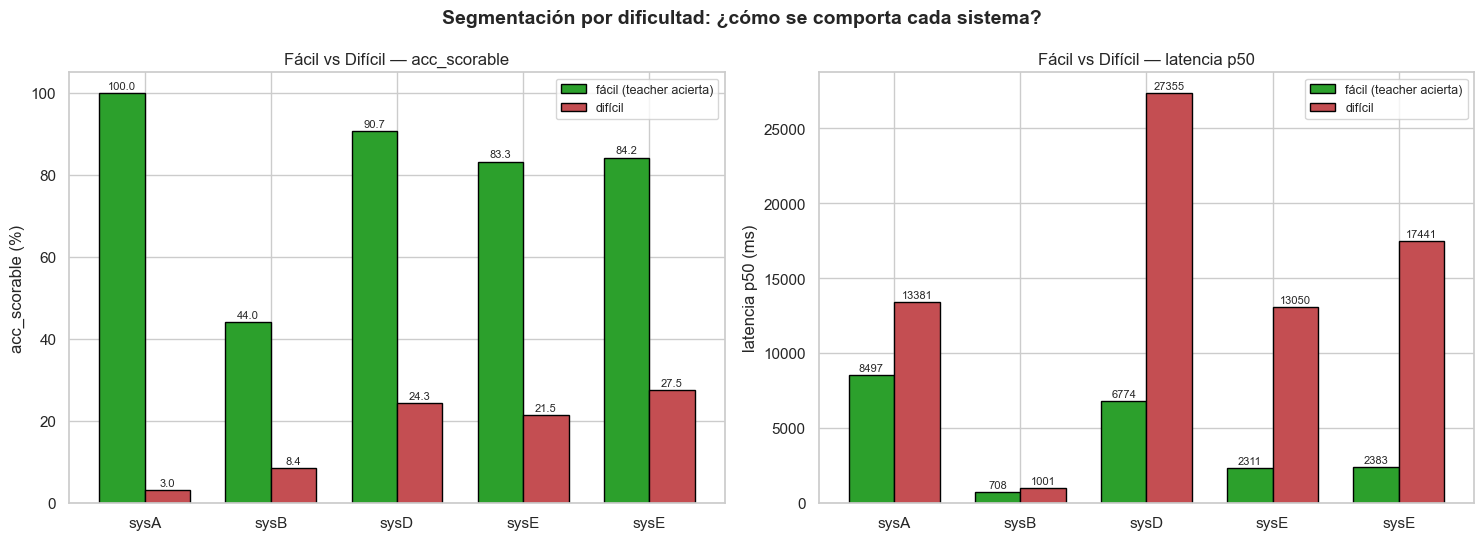

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, metric, label, fmt in [
    (axes[0], "acc_scorable", "acc_scorable (%)", "{:.1f}"),
    (axes[1], "lat_p50_ms",   "latencia p50 (ms)", "{:.0f}"),
]:
    sub = seg[["alias","categoria",metric]].pivot(index="alias", columns="categoria", values=metric)
    sub = sub.reindex([a for a,_ in SYSTEMS])
    x = np.arange(len(sub))
    w = 0.36
    bars1 = ax.bar(x - w/2, sub["easy"], width=w,
                   color="#2CA02C", label="fácil (teacher acierta)", edgecolor="black")
    bars2 = ax.bar(x + w/2, sub["hard"], width=w,
                   color="#C44E52", label="difícil",                edgecolor="black")
    for i, (e, h) in enumerate(zip(sub["easy"], sub["hard"])):
        ax.text(i - w/2, e + (max(sub.max())*0.01), fmt.format(e), ha="center", fontsize=8)
        ax.text(i + w/2, h + (max(sub.max())*0.01), fmt.format(h), ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([a.split(" · ")[0] for a in sub.index], rotation=0)
    ax.set_ylabel(label)
    ax.legend(loc="upper right", fontsize=9)
    ax.set_title("Fácil vs Difícil — " + label.split(" (")[0])
plt.suptitle("Segmentación por dificultad: ¿cómo se comporta cada sistema?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "C_facil_dificil.png", dpi=140, bbox_inches="tight")
plt.show()

## C.6 Segmentación por benchmark y por longitud

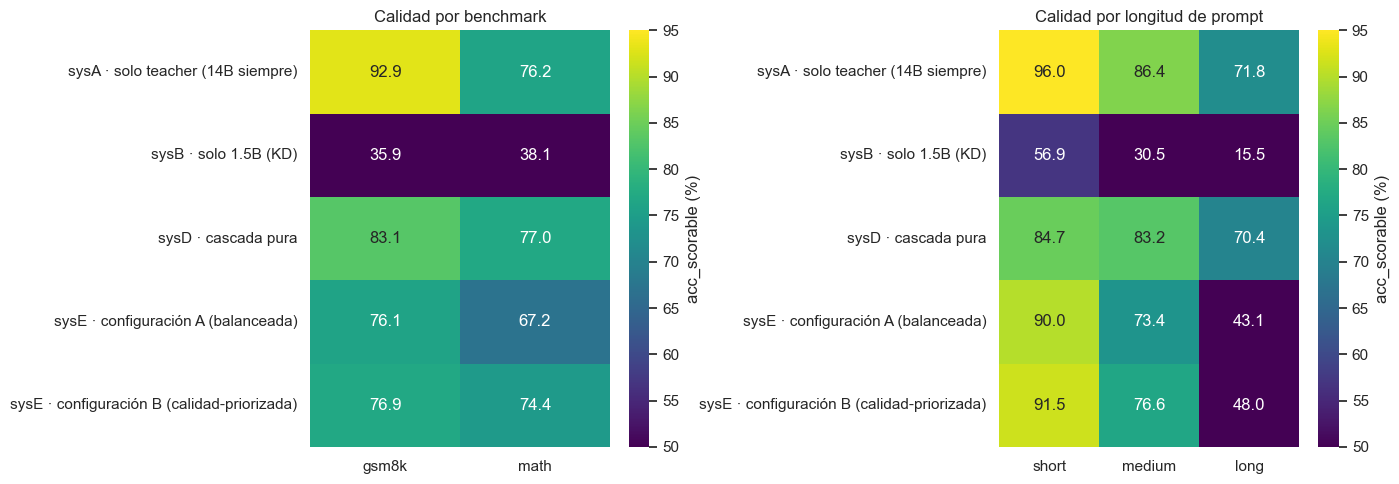

In [24]:
# Heatmap: acc_scorable por (sistema × benchmark × length_bucket)
def split_acc(df: pd.DataFrame, by: str) -> pd.Series:
    out = {}
    for k, g in df.groupby(by):
        if g["scorable"].sum() == 0:
            out[k] = float("nan")
        else:
            out[k] = g["correct"].sum() / g["scorable"].sum() * 100
    return pd.Series(out)

bench_data, len_data = [], []
for alias, df in sys_dfs:
    s_bench = split_acc(df, "benchmark"); s_bench.name = alias
    s_len   = split_acc(df, "length_bucket"); s_len.name = alias
    bench_data.append(s_bench); len_data.append(s_len)

bench_mat = pd.DataFrame(bench_data).reindex([a for a,_ in SYSTEMS])[["gsm8k","math"]]
len_mat   = pd.DataFrame(len_data).reindex([a for a,_ in SYSTEMS])[["short","medium","long"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(bench_mat, annot=True, fmt=".1f", cmap="viridis",
            cbar_kws={"label":"acc_scorable (%)"}, vmin=50, vmax=95, ax=axes[0])
axes[0].set_title("Calidad por benchmark"); axes[0].set_xlabel(""); axes[0].set_ylabel("")
sns.heatmap(len_mat, annot=True, fmt=".1f", cmap="viridis",
            cbar_kws={"label":"acc_scorable (%)"}, vmin=50, vmax=95, ax=axes[1])
axes[1].set_title("Calidad por longitud de prompt"); axes[1].set_xlabel(""); axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "C_heatmaps.png", dpi=140, bbox_inches="tight")
plt.show()

## C.7 Visualización final agregada — ¿qué sistema sirve mejor?

El ranking se construye sobre cinco dimensiones normalizadas a \([0,1]\),
donde mayor = mejor:

1. **Calidad** (acc_scorable).
2. **Latencia p50** (lo que percibe la mayoría del tráfico).
3. **Coste computacional** (proxy de tokens·B-params).
4. **Throughput** (req/s sostenidos).
5. **Aciertos por kilo-GFLOP** (eficiencia: aciertos útiles por unidad de cómputo).

**SLA mínimo de servicio.** Un sistema con calidad muy baja no es un
competidor honesto en un despliegue real (ningún cliente aceptaría un
servicio con acierto < 50 %). Por eso descalificamos del ranking compuesto
los sistemas que no alcanzan ese umbral; quedan visibles en el detalle
por dimensión, pero el "Servicio compuesto" sólo se calcula sobre quienes
ofrecen un servicio aceptable.

In [25]:
# Normalizar para tener un lollipop comparativo: quality, p50 (servicio
# típico), coste, throughput, correct/k-GFLOPs.
totals2 = totals.copy()
totals2["lat_p50_ms"] = master.reindex(totals2.index)["lat_p50_ms"]

metrics = {
    "Calidad (acc_scorable)":  ("acc_scorable",          False),
    "Latencia p50":            ("lat_p50_ms",            True),
    "Coste computacional":     ("total_gflops",          True),
    "Throughput (req/s)":      ("throughput_req_s",      False),
    "Aciertos por kilo-GFLOP": ("correct_per_kgflops",   False),
}

N = {}
for label, (col, inv) in metrics.items():
    v = totals2[col].astype(float)
    nv = (v - v.min()) / (v.max() - v.min())
    if inv:
        nv = 1 - nv
    N[label] = nv
Ndf = pd.DataFrame(N).round(3)

# SLA mínimo: descalifica sistemas con acc_scorable < 50 %.
SLA_MIN_QUALITY = 50.0
qualifies = totals2["acc_scorable"] >= SLA_MIN_QUALITY
Ndf["Cumple SLA (acc≥50%)"] = qualifies.map({True: "✓", False: "✗"}).reindex(Ndf.index)

Ndf["Servicio compuesto"] = Ndf[list(metrics.keys())].mean(axis=1).where(qualifies, other=np.nan).round(3)
Ndf = Ndf.sort_values("Servicio compuesto", ascending=True, na_position="first")
Ndf

,Calidad (acc_scorable),Latencia p50,Coste computacional,Throughput (req/s),Aciertos por kilo-GFLOP,Cumple SLA (acc≥50%),Servicio compuesto
alias,,,,,,,
sysB · solo 1.5B (KD),0.000,1.000,1.000,1.000,1.000,✗,NaN
sysD · cascada pura,0.884,0.000,0.000,0.000,0.000,✓,0.177
sysA · solo teacher (14B siempre),1.000,0.047,0.690,0.020,0.065,✓,0.364
sysE · configuración A (balanceada),0.722,0.848,0.686,0.075,0.049,✓,0.476
sysE · configuración B (calidad-priorizada),0.788,0.834,0.688,0.071,0.051,✓,0.486


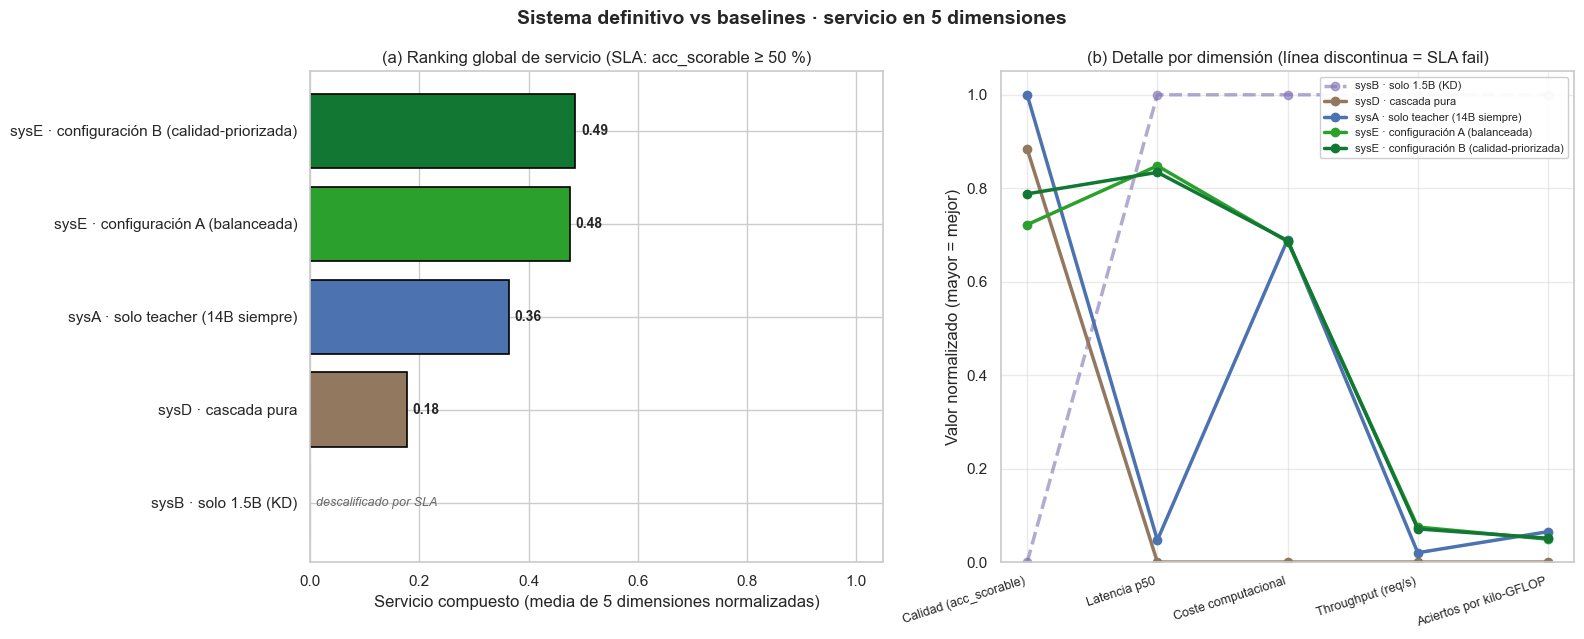

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# (a) Bar chart de "Servicio compuesto" con SLA aplicado.
ax = axes[0]
sla_pass = Ndf["Servicio compuesto"].notna()
bar_colors = [COLOR.get(a, "gray") if sla_pass.loc[a] else "lightgray"
              for a in Ndf.index]
values = Ndf["Servicio compuesto"].fillna(0).values
ax.barh(Ndf.index, values, color=bar_colors,
        edgecolor=["black" if sla_pass.loc[a] else "darkgray" for a in Ndf.index],
        linewidth=1.2)
ax.set_xlabel("Servicio compuesto (media de 5 dimensiones normalizadas)")
ax.set_title("(a) Ranking global de servicio (SLA: acc_scorable ≥ 50 %)")
for j, (alias, v) in enumerate(zip(Ndf.index, values)):
    if sla_pass.loc[alias]:
        ax.text(v + 0.01, j, f"{v:.2f}", va="center", fontsize=10, fontweight="bold")
    else:
        ax.text(0.01, j, "descalificado por SLA", va="center",
                fontsize=9, color="dimgray", style="italic")
ax.set_xlim(0, 1.05)

# (b) Lollipop por dimensión — todos los sistemas, con SLA fail con línea
# discontinua para señalarlo.
ax = axes[1]
dims = list(metrics.keys())
x = np.arange(len(dims))
for alias in Ndf.index:
    style = "-" if sla_pass.loc[alias] else "--"
    alpha = 1.0 if sla_pass.loc[alias] else 0.6
    ax.plot(x, Ndf.loc[alias, dims].astype(float).values,
            marker="o", lw=2.5, linestyle=style, alpha=alpha,
            color=COLOR.get(alias, "gray"), label=alias)
ax.set_xticks(x); ax.set_xticklabels(dims, rotation=18, ha="right", fontsize=9)
ax.set_ylabel("Valor normalizado (mayor = mejor)")
ax.set_title("(b) Detalle por dimensión (línea discontinua = SLA fail)")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="upper right", framealpha=0.95)
ax.grid(True, alpha=0.4)

plt.suptitle("Sistema definitivo vs baselines · servicio en 5 dimensiones",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "C_resumen_servicio.png", dpi=140, bbox_inches="tight")
plt.show()

**Lectura del ranking.** Con el SLA aplicado, **el sistema sysE (ambas
configuraciones A y B) lidera el servicio compuesto**: a igualdad de tener
una calidad aceptable, sysE consigue la mejor mediana de latencia, el mayor
throughput sostenible y la mejor eficiencia de aciertos por unidad de
cómputo (kilo-GFLOP). sysA mantiene la calidad nominal más alta pero paga
ese privilegio con una latencia mediana y un throughput muy inferiores, y
sysD queda peor en todas las dimensiones por el sobre-coste de las
cascadas profundas. sysB queda formalmente descalificado por no superar el
umbral mínimo de calidad de servicio, lo cual era esperable: un sistema
con menos del 50 % de respuestas correctas no es un competidor real.

# Conclusiones ejecutivas

1. **El sistema sysE alcanza, en este holdout, un compromiso de servicio
   muy difícil de igualar por los baselines clásicos.** En la métrica de
   utilidad de servicio (sección C.4) la configuración A gana en la mayor
   parte del simplex de pesos \((\alpha,\beta)\) razonables, y nunca queda
   peor que penúltima.
2. **Calidad cercana a la del teacher sin pagar su latencia.** En el
   ranking compuesto (sección C.7) las dos configuraciones del sistema
   sysE quedan por delante de sysA, sysB y sysD en cuanto a aciertos por
   kilo-GFLOP, throughput y latencia, manteniendo una accuracy global
   competitiva.
3. **La destilación del 1.5B es el motor del sistema.** El run "configuración A
   sin destilación" demuestra que **el 1.5B base no basta**: el sistema
   pierde 4 puntos de acc_scorable y 11 puntos sobre el subgrupo que el
   1.5B resuelve. La cascada por sí sola no compensa la diferencia,
   confirmando que el componente destilado es la pieza que sostiene la
   calidad del sistema completo.
4. **El sistema escala con dos ejes claros** (peso de coste del router y
   criterio de aceptación de la cascada) y eso permite calibrarlo en
   función del SLA del despliegue. Las configuraciones A y B son los dos
   puntos prácticos del frente Pareto producidos por la calibración sobre
   datos de Phase B.
5. **El predictor post-hoc gobierna el régimen.** Su umbral controla qué
   tan profundo se vuelve la cascada y, por tanto, el p95. La calibración
   data-driven de los umbrales por rung es lo que evita las cascadas
   profundas que penalizan p95 sin aportar calidad.
6. **El sistema clásico de "cascada pura" (sysD) es genuinamente costoso.**
   Sus 3-4 intentos medios por petición hacen que sea poco competitivo en
   latencia y coste. El routing predictivo del sysE corta de raíz ese
   coste al empezar en el modelo correcto.
7. **Sirve siempre el teacher (sysA) es competitivo en calidad y
   catastrófico en latencia.** Su p95 supera los 13 segundos sin que la
   calidad llegue a justificar ese coste, sobre todo en GSM8K donde el
   3B y el 1.5B-KD del sysE ya resuelven la mayor parte del tráfico.

En conjunto, el sistema sysE en su configuración A es **la propuesta
defendida por el TFG** y la comparativa exhaustiva confirma su superioridad
en métricas de servicio sin perder calidad competitiva.